In [2]:
from pathlib import Path

import pandas as pd
from IPython.display import display

from pep_compass.analysis import ExperimentAnalysis
from pep_compass.analysis.reader import ExperimentReader


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not locate pyproject.toml')


In [3]:
REPOSITORY_ROOT = find_repository_root(Path.cwd())
RESULTS_PATH = REPOSITORY_ROOT / "experiments/results/locality_experiments_latent_escaping_08_13_26/run"

reader = ExperimentReader(RESULTS_PATH)
selection = reader.select()
# use_cache=True: latent_jump's encoding pass is the expensive part, cached in
# .pep_compass_analysis.sqlite next to RESULTS_PATH, keyed by input file
# mtimes/sizes + parameters. Re-running this cell after editing a plot below
# does not re-encode anything.
analysis = ExperimentAnalysis(selection, plot_theme="paper", use_cache=True)

print(f"{len(selection.runs)} runs selected")


18 runs selected


# SORBES movement, then latent jump vs. edit distance

First: does SORBES actually move for each seed? Then split the jump analysis by that, since pooling stationary and moving seeds together dilutes the effect we care about.


`sorbes_moved` (per run/seed, not per trajectory): `True` if any of that seed's 100 walk points (10 trajectories x 10 iterations) decoded to more than one distinct sequence, `False` if all 100 are identical to the seed.

```python
# latent_jump.py
sorbes_moved = points["sequence"].nunique() > 1
```


In [7]:
profile = analysis.locality.sorbes_trajectory_profile()

In [8]:
seed_sequences = sorted(profile.metadata["seeds_moved"] + profile.metadata["seeds_stationary"])
peptides_csv = pd.read_csv(REPOSITORY_ROOT / "assets/peptides_data/peptides.csv")
matches = peptides_csv[peptides_csv["sequence"].isin(seed_sequences)]

print(f"{len(seed_sequences)} unikalnych sekwencji startowych w tym eksperymencie")
print(f"{len(matches)} z nich znaleziono w peptides.csv (zbiór treningowy HydrAMP, {len(peptides_csv)} sekwencji)")
if matches.empty:
    print()
    print("Żadna z 6 sekwencji startowych nie pochodzi z peptides.csv -- to nie są peptydy ze zbioru treningowego HydrAMP.")
else:
    display(matches[["sequence", "dataset"]])


6 unikalnych sekwencji startowych w tym eksperymencie
0 z nich znaleziono w peptides.csv (zbiór treningowy HydrAMP, 305163 sekwencji)

Żadna z 6 sekwencji startowych nie pochodzi z peptides.csv -- to nie są peptydy ze zbioru treningowego HydrAMP.


{'analysis': 'sorbes_trajectory_profile',
 'run_count': 18,
 'seeds_moved': ['KFRNRHRWKFKLIFRN',
  'KKYWLIRKWIRLWFLT',
  'RMARNLVRYVQGLKKKKVI'],
 'seeds_stationary': ['FLYKWWIRIGRLKL', 'KTLKIIRLLF', 'KYCRRFRWLTFRWL'],
 'walk_point_count': 1800}

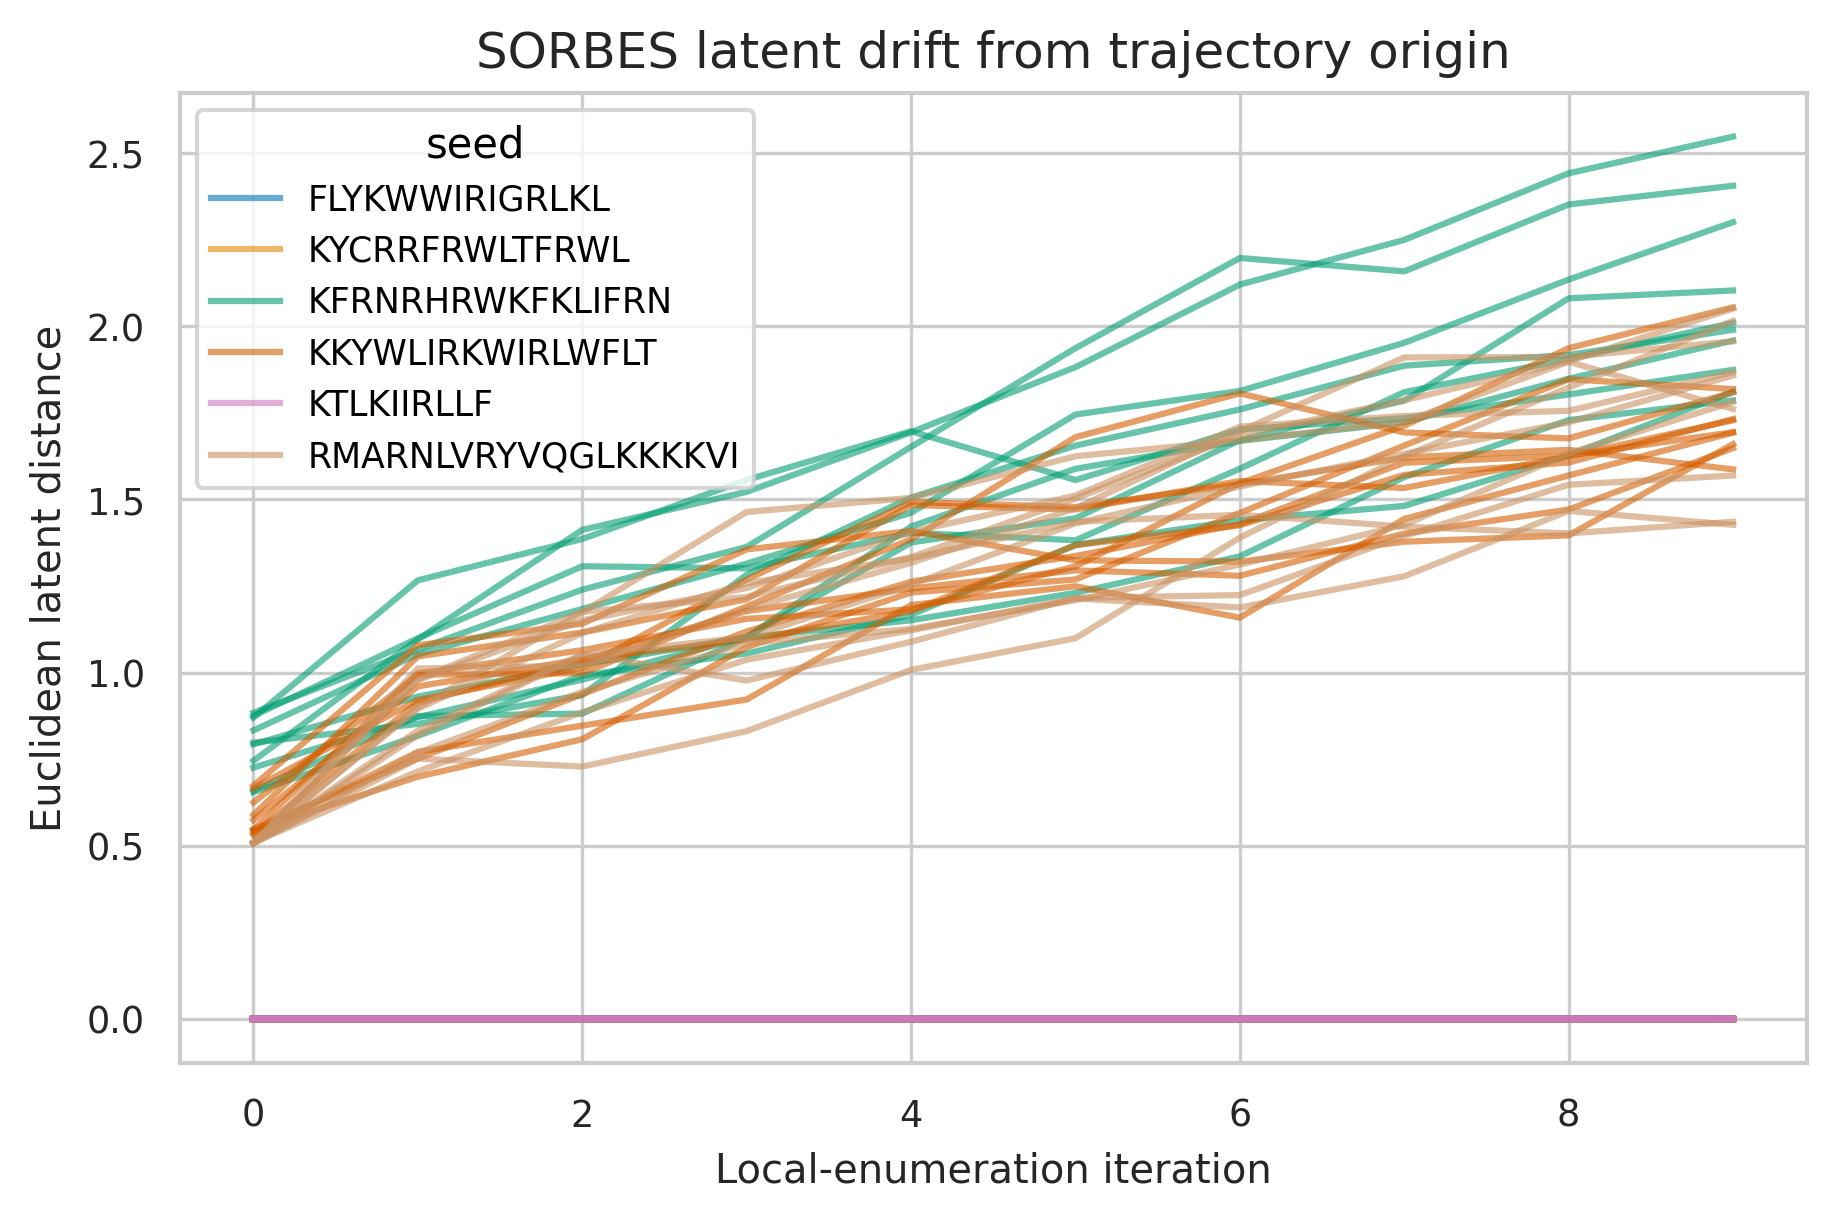

In [5]:
import matplotlib.pyplot as plt

display(profile.metadata)
axes = analysis.visualize.locality.sorbes_trajectory_profile(profile)
display(axes.figure)
plt.close(axes.figure)


**Wniosek:** 3 z 6 peptydów startowych (`FLYKWWIRIGRLKL`, `KYCRRFRWLTFRWL`, `KTLKIIRLLF`) mają SORBES praktycznie nieruchomy przez wszystkie 10 iteracji x 10 trajektorii -- płaska linia na 0. Pozostałe 3 rosną w miarę monotonicznie z iteracją. To dzieli dalszą analizę na dwie grupy (`sorbes_moved`), bo uśrednianie ich razem zaciera efekt, którym się interesujemy -- patrz niżej.


In [6]:
result = analysis.locality.latent_jump()


In [7]:
display(result.metadata)

{'analysis': 'latent_jump',
 'autoencoder': {'field_eps': 0.001,
  'jacobian_eps': 0.001,
  'jacobian_mode': 'approx',
  'model_name': 'article_25'},
 'candidate_sample_size': 20000,
 'outlier_iqr_multiplier': 3.0,
 'run_count': 18,
 'total_mutang_candidates_analyzed': 126532,
 'total_walk_points': 1800,
 'unmatched_sorbes_parents': 0}

## Trzy dystanse w latencie, po kolejnych iteracjach

Dla każdej iteracji SORBES (0-9): rozkład trzech dystansów euklidesowych -- odległość kandydata od sekwencji początkowej (`candidate_to_origin`), odległość kandydata od punktu SORBES, z którego został wygenerowany (`candidate_to_sorbes_parent`), i odległość samego punktu SORBES od sekwencji początkowej (`sorbes_to_origin`).

To surowy obraz: jak te odległości rosną w czasie, bez odnoszenia ich jeszcze do liczby mutacji. Dopiero w kolejnej sekcji sprawdzamy, czy ten wzrost wiąże się sensownie z odległością Levenshteina (liczbą różniących się aminokwasów), czy to w ogóle ma sens jako hipoteza.


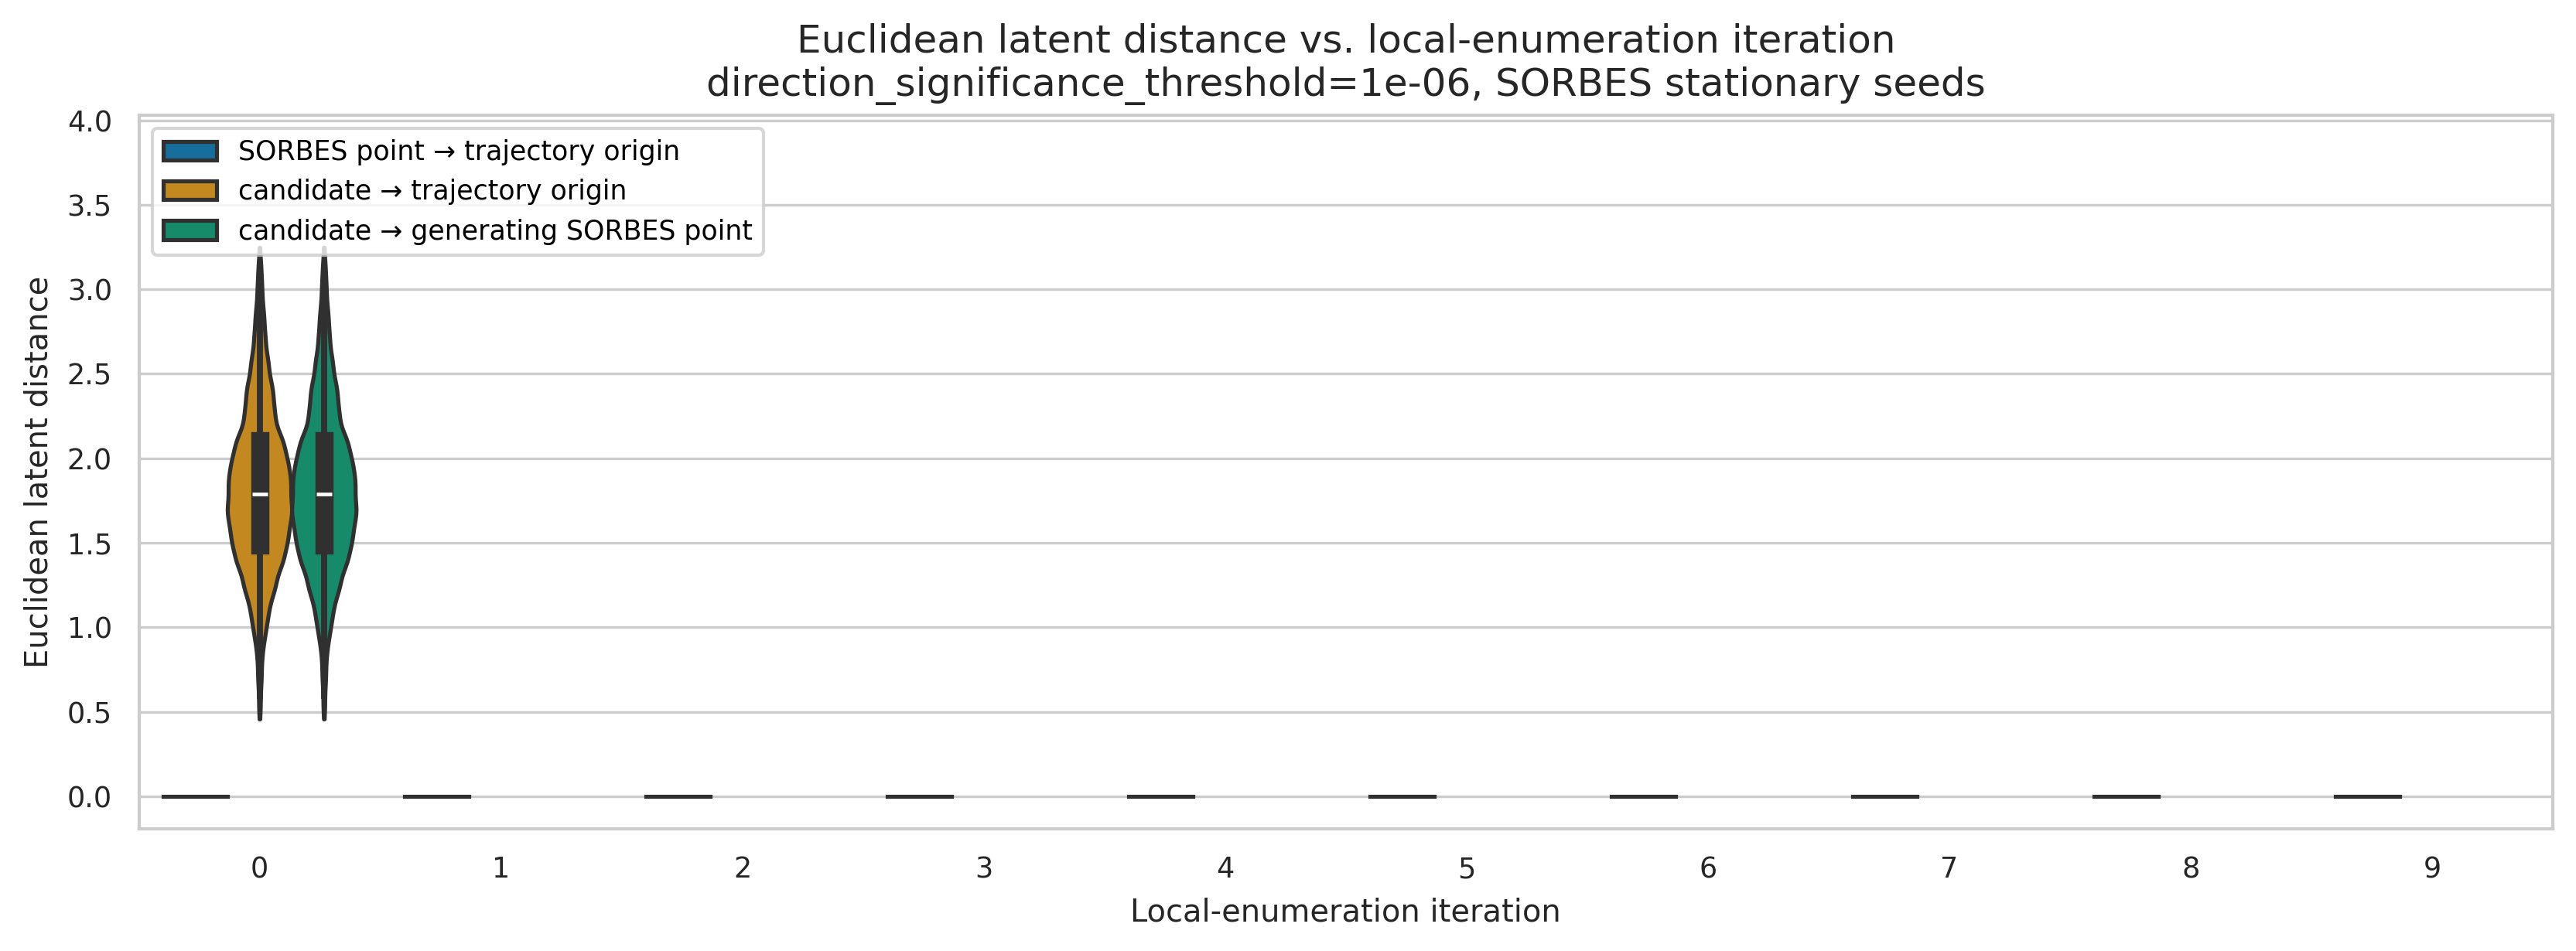

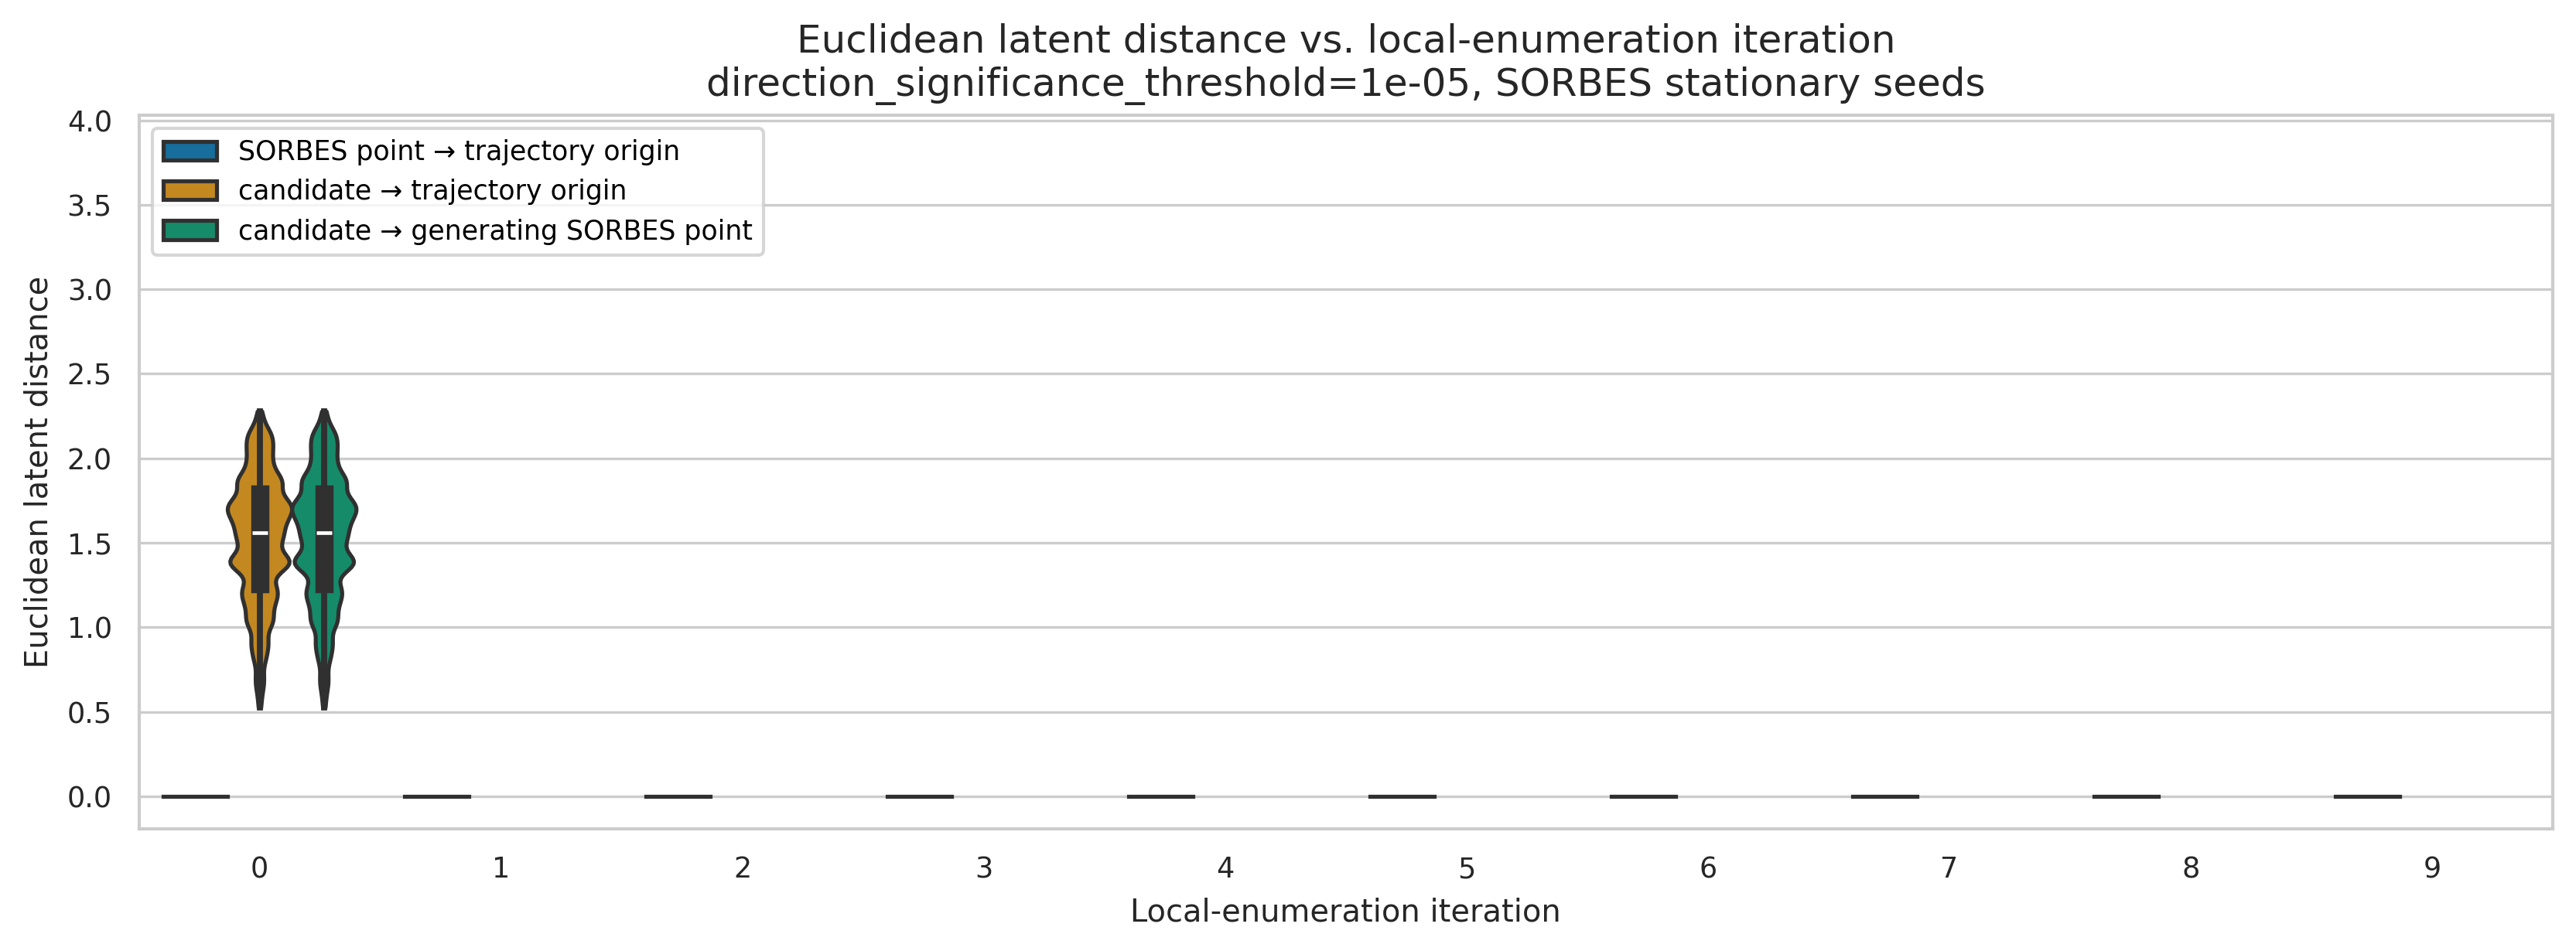

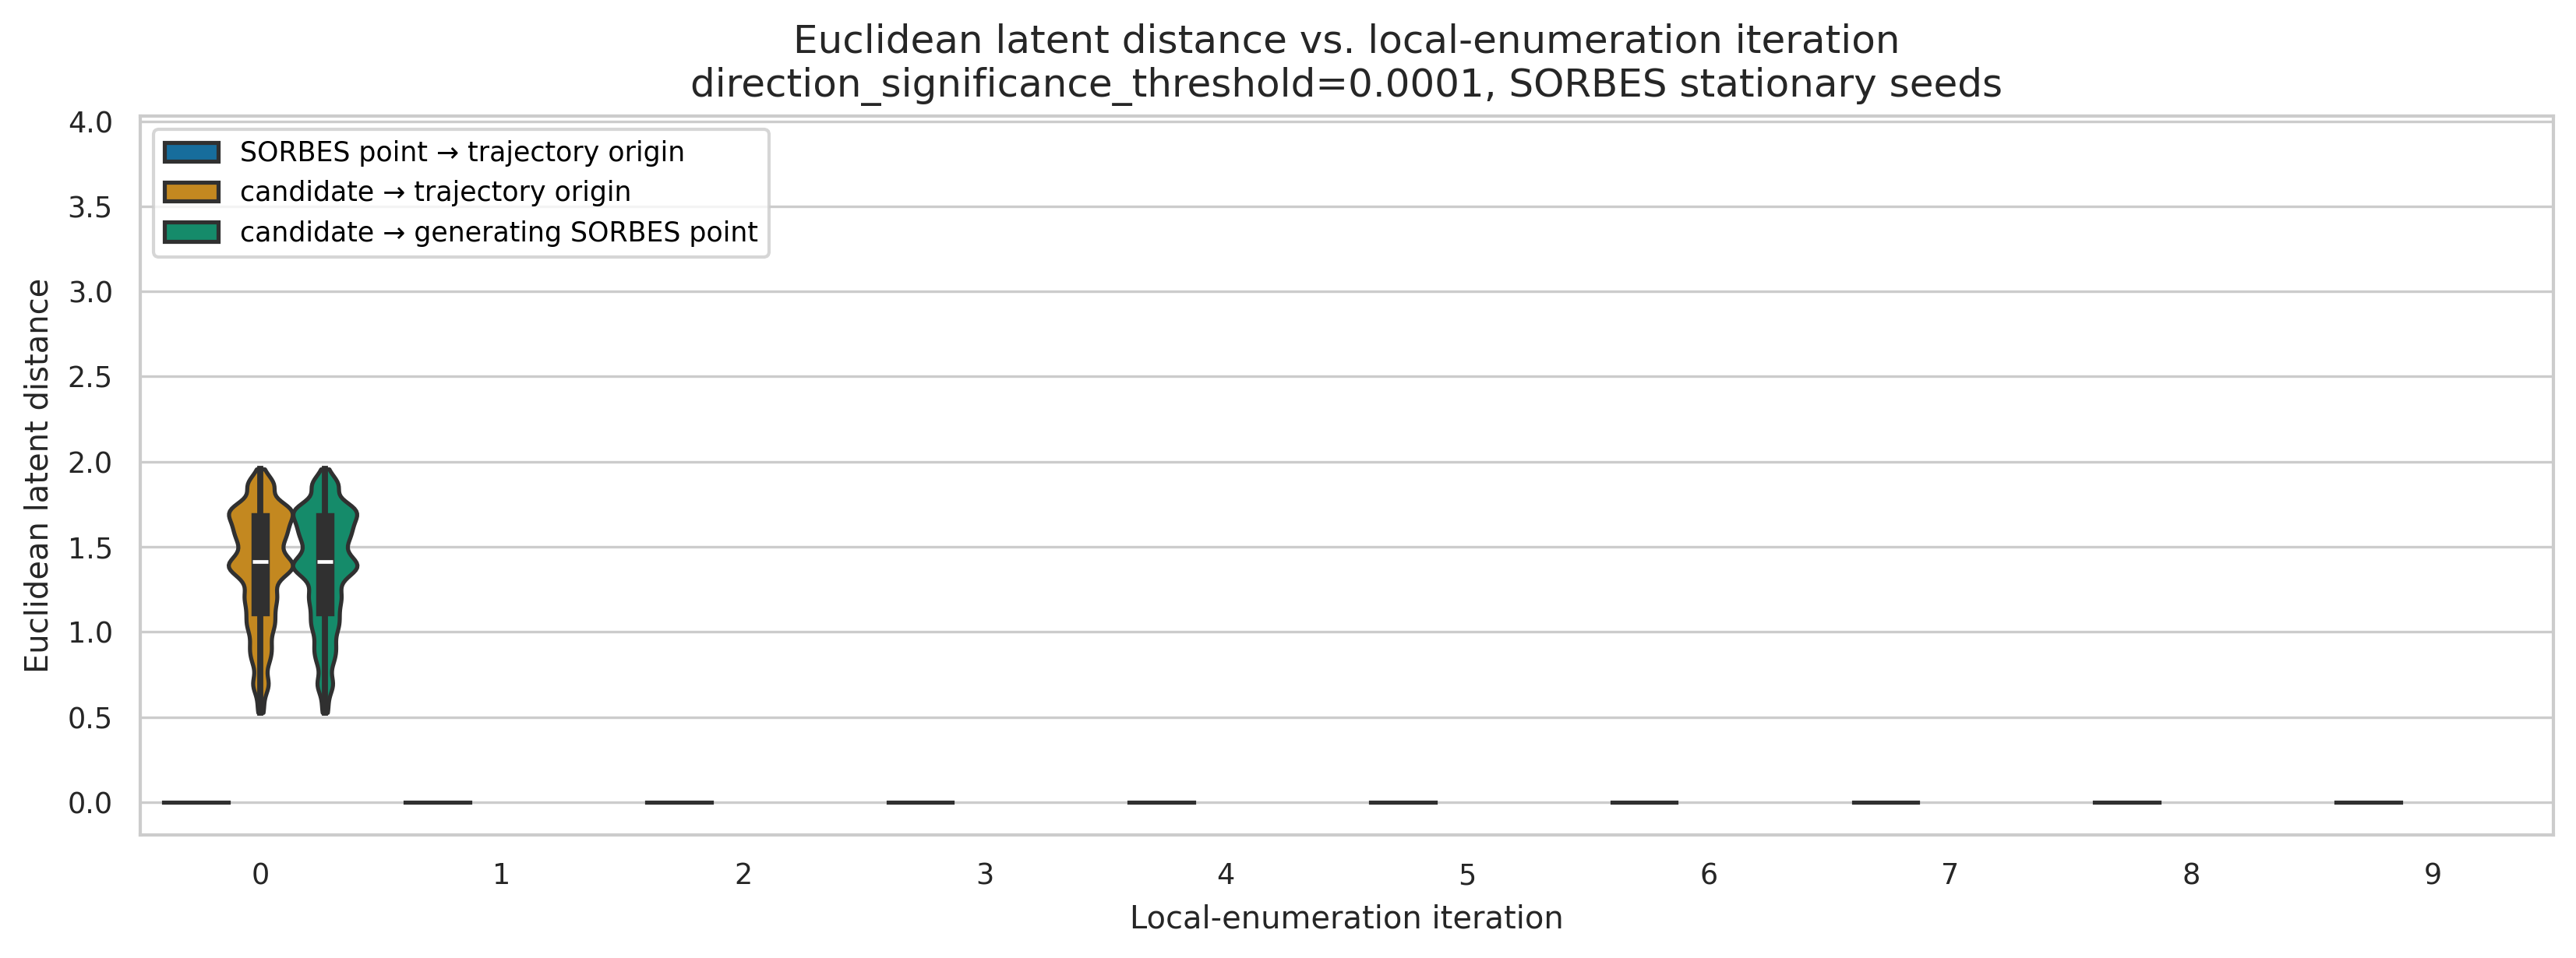

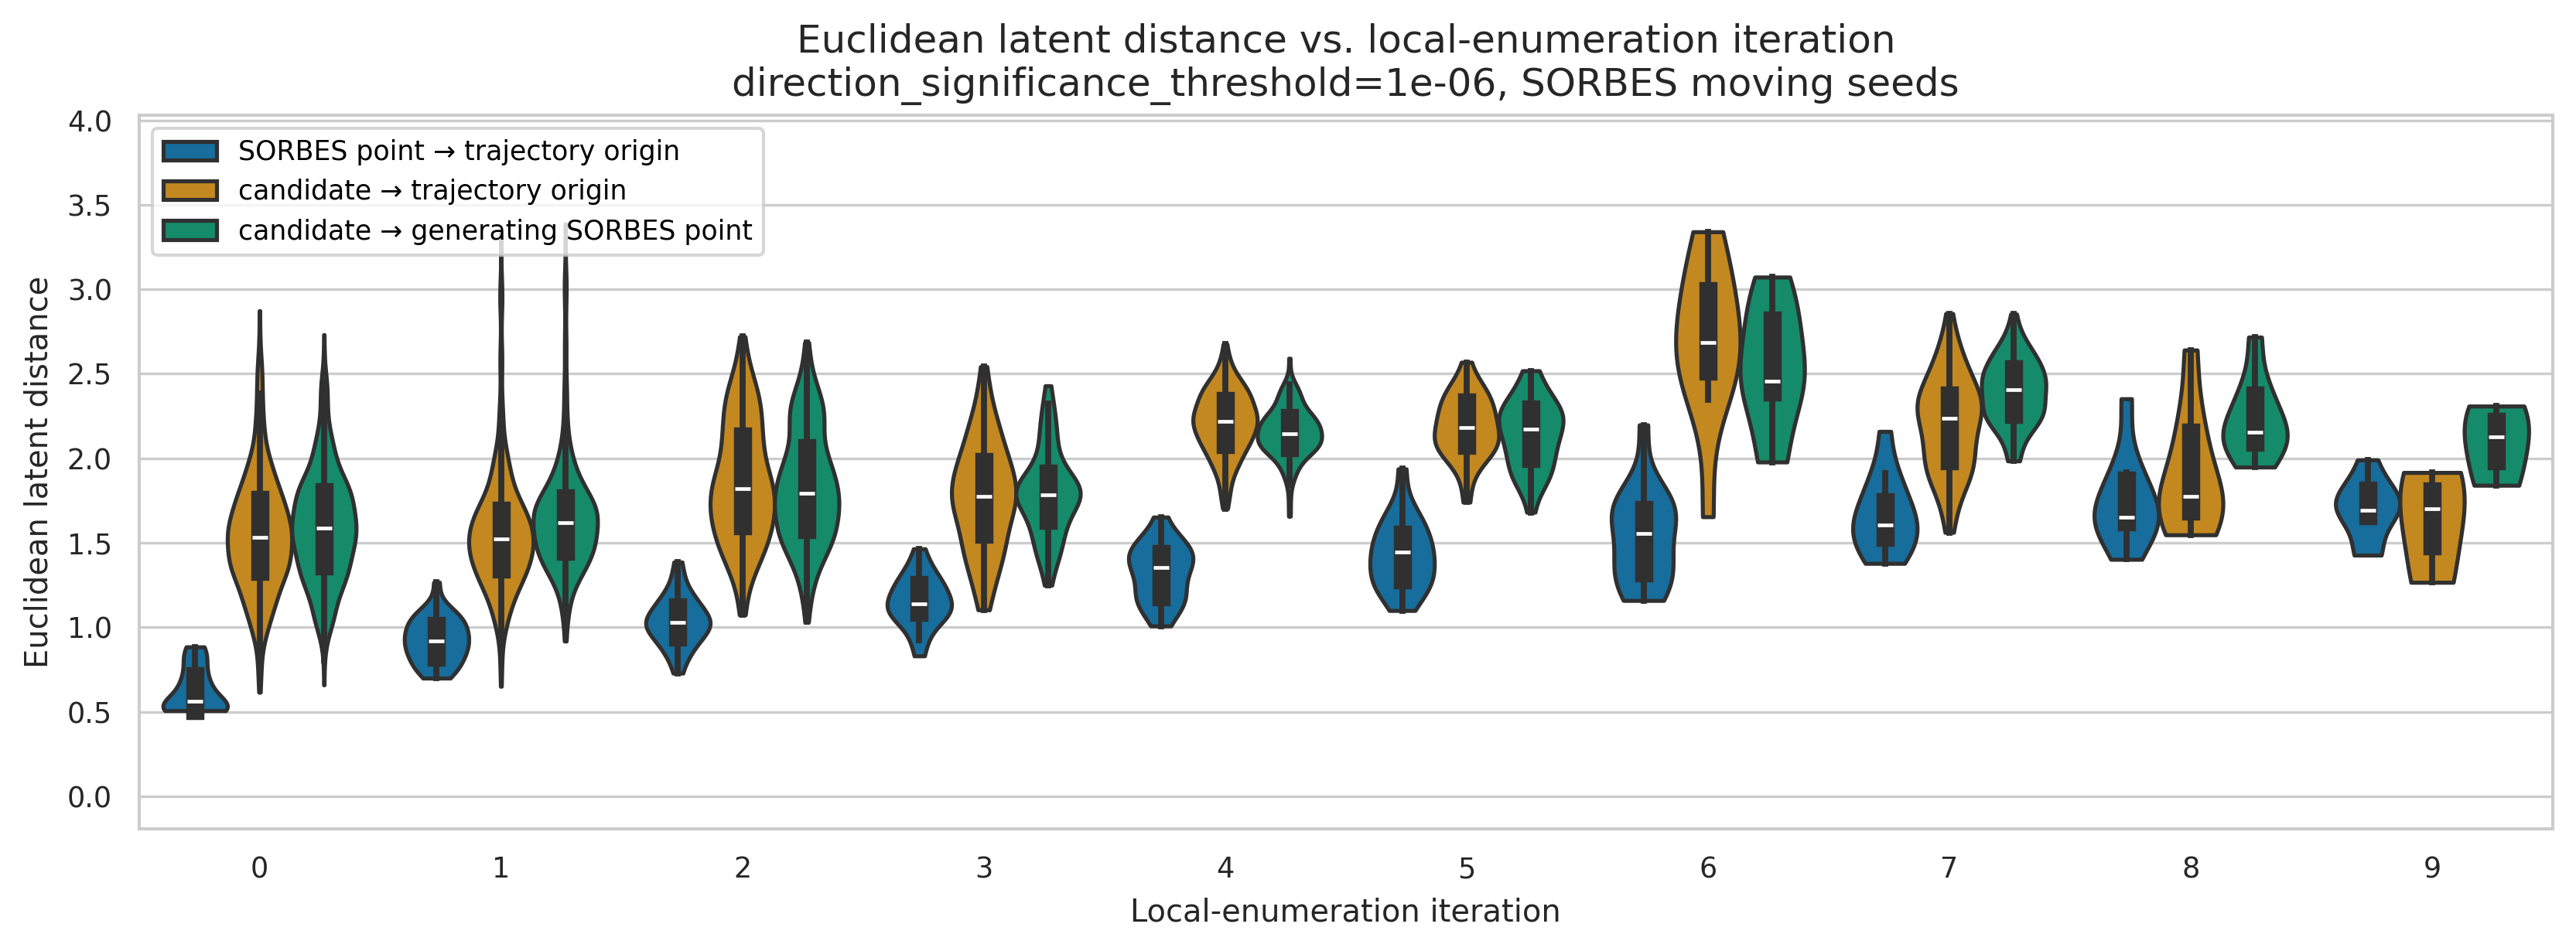

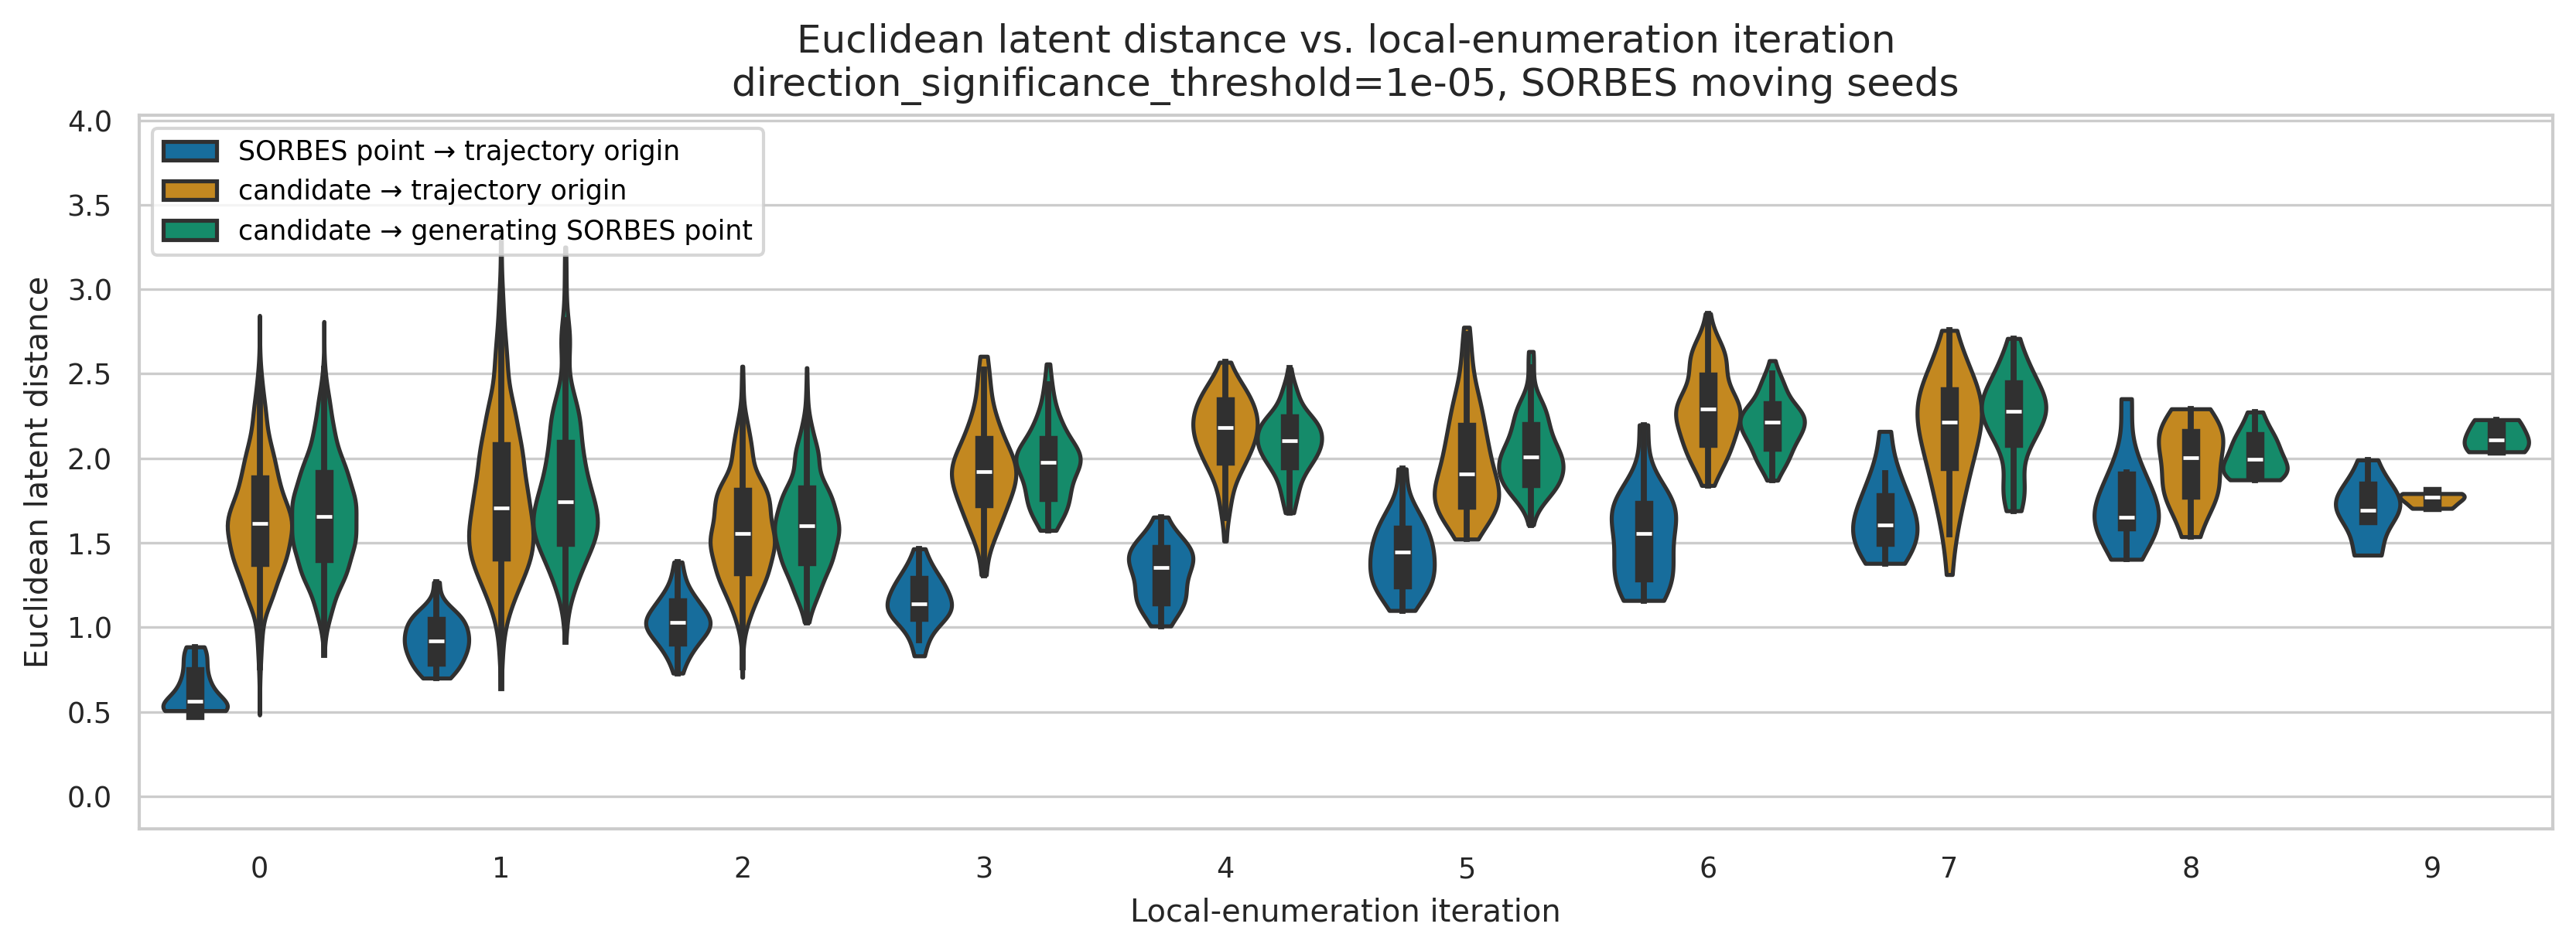

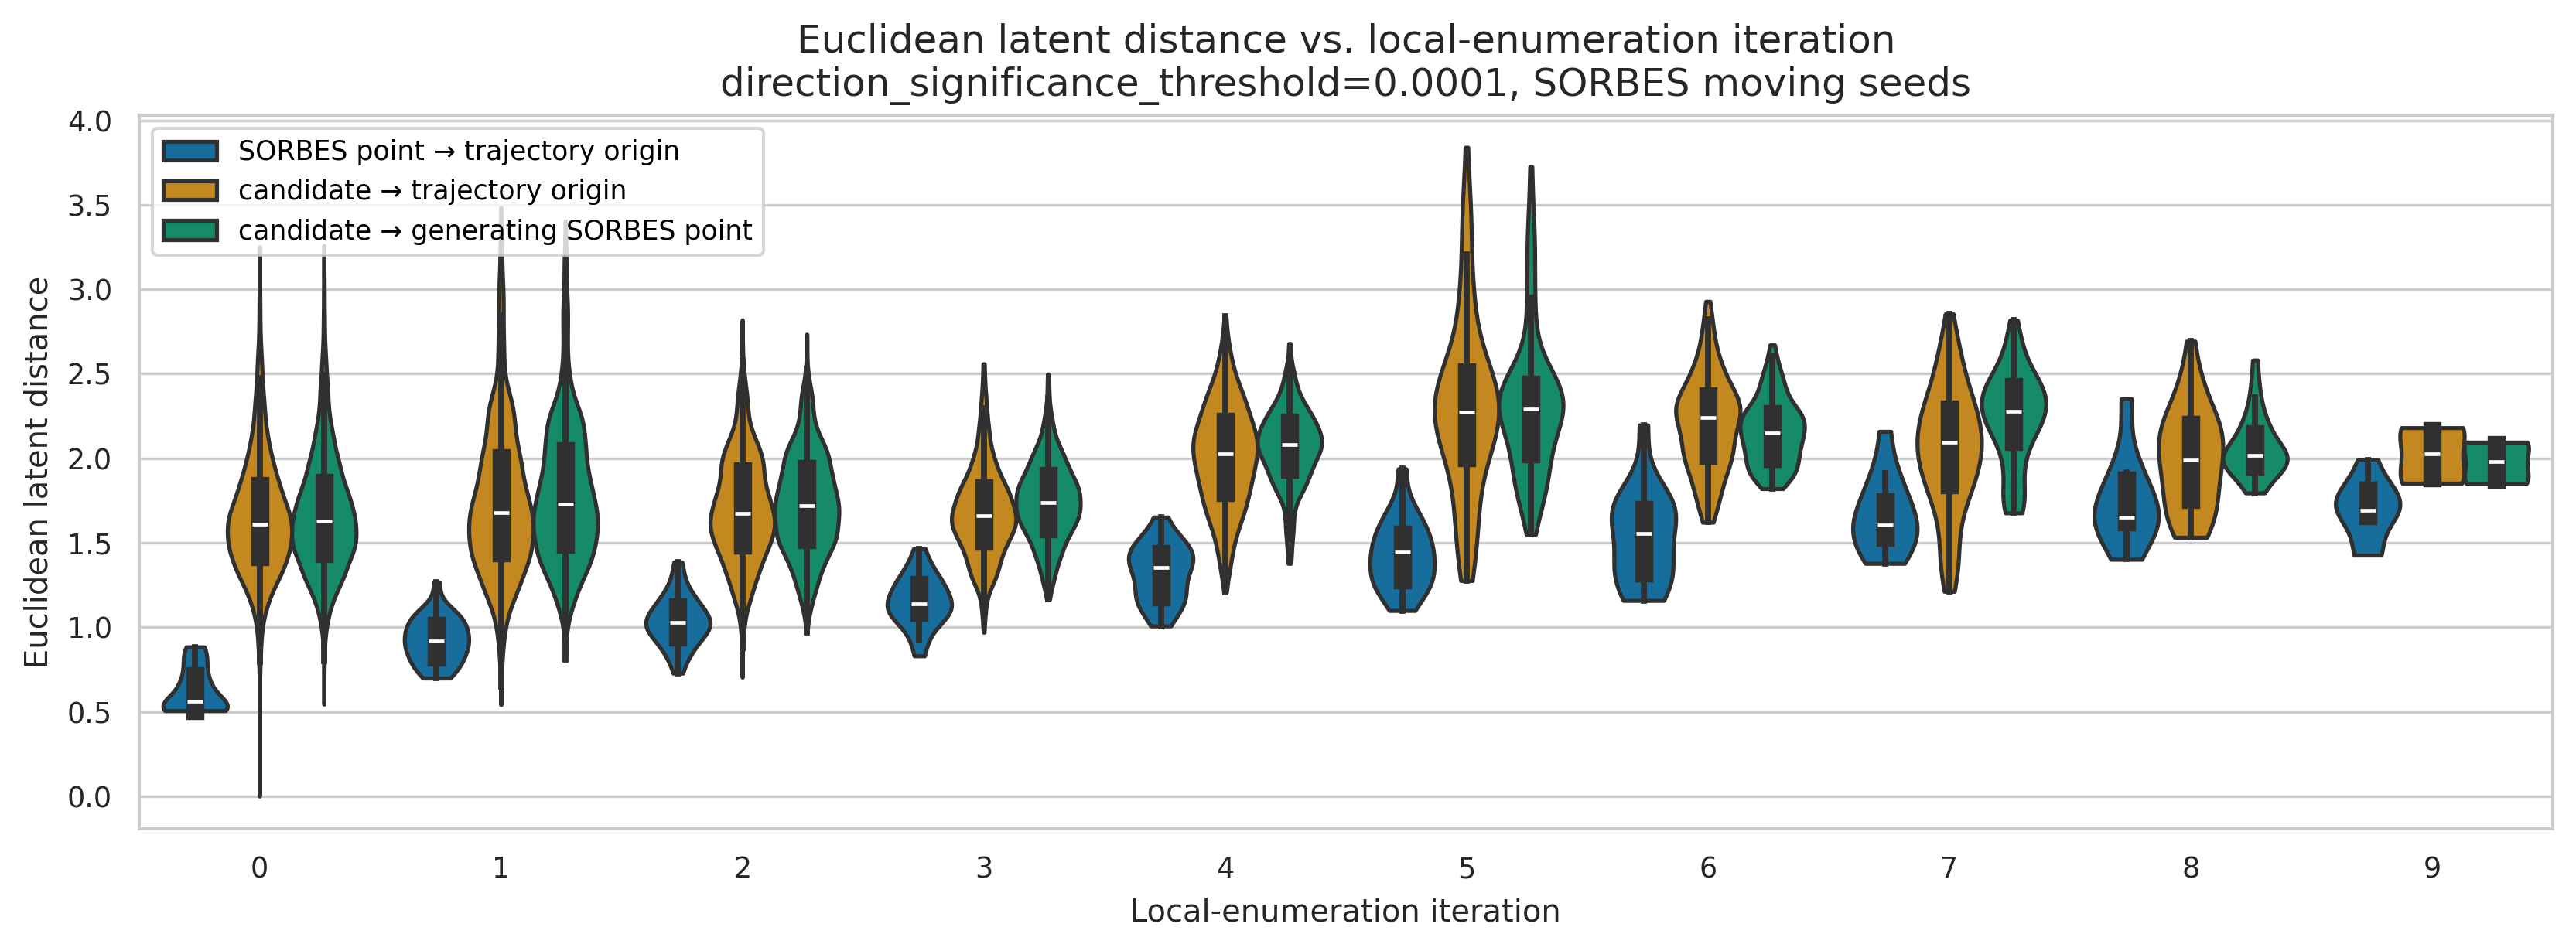

In [8]:
figures_by_iteration = analysis.visualize.locality.latent_jump_by_iteration(result)
analysis.visualize.locality.share_y_limits(figures_by_iteration)
for (sorbes_moved, grid_value), axes in figures_by_iteration.items():
    display(axes.figure)
    plt.close(axes.figure)


**Wniosek:** dla grupy `moving` wszystkie trzy dystanse rosną z iteracją (widać to samo zjawisko co na wykresie profilu SORBES wyżej, tylko teraz z rozkładem, nie pojedynczą linią) -- pomarańczowy/zielony podążają blisko za niebieskim, przesunięte w górę o typowy rozmiar skoku mutacji. Dla `stationary` (nie pokazane wyżej, ale w wynikach) niebieski siedzi płasko przy 0 na każdej iteracji, pomarańczowy i zielony pokrywają się -- spójne z wcześniejszym wnioskiem o `sorbes_moved`.


## To samo, ale względem liczby mutacji (Levenshtein)

Ta sama trójka dystansów co wyżej, ale teraz oś X to liczba różniących się aminokwasów (`levenshtein_distance`), nie iteracja -- sprawdzamy, czy wzrost dystansu euklidesowego, który widzieliśmy powyżej jako funkcję czasu, da się też sensownie wytłumaczyć liczbą mutacji.


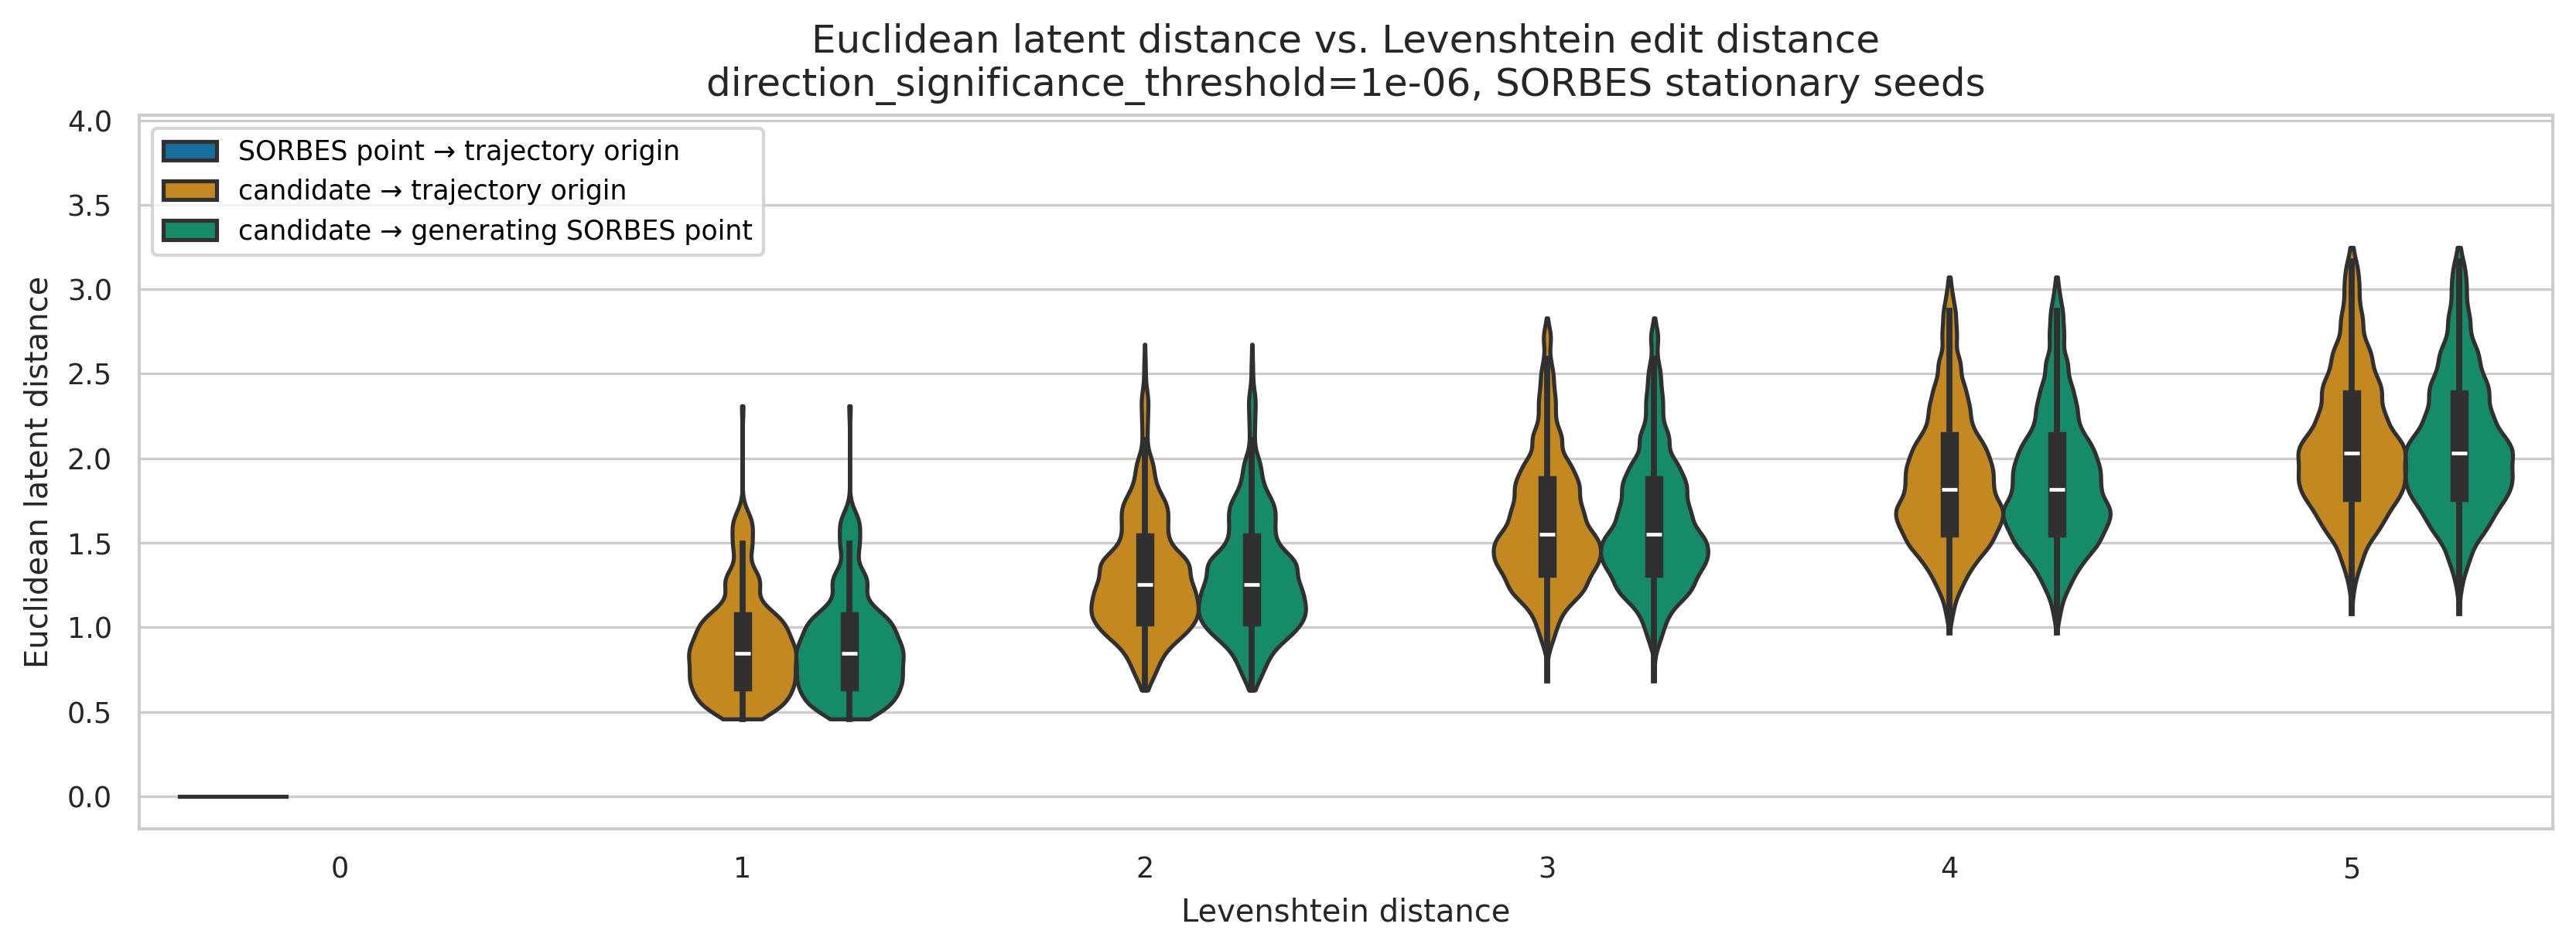

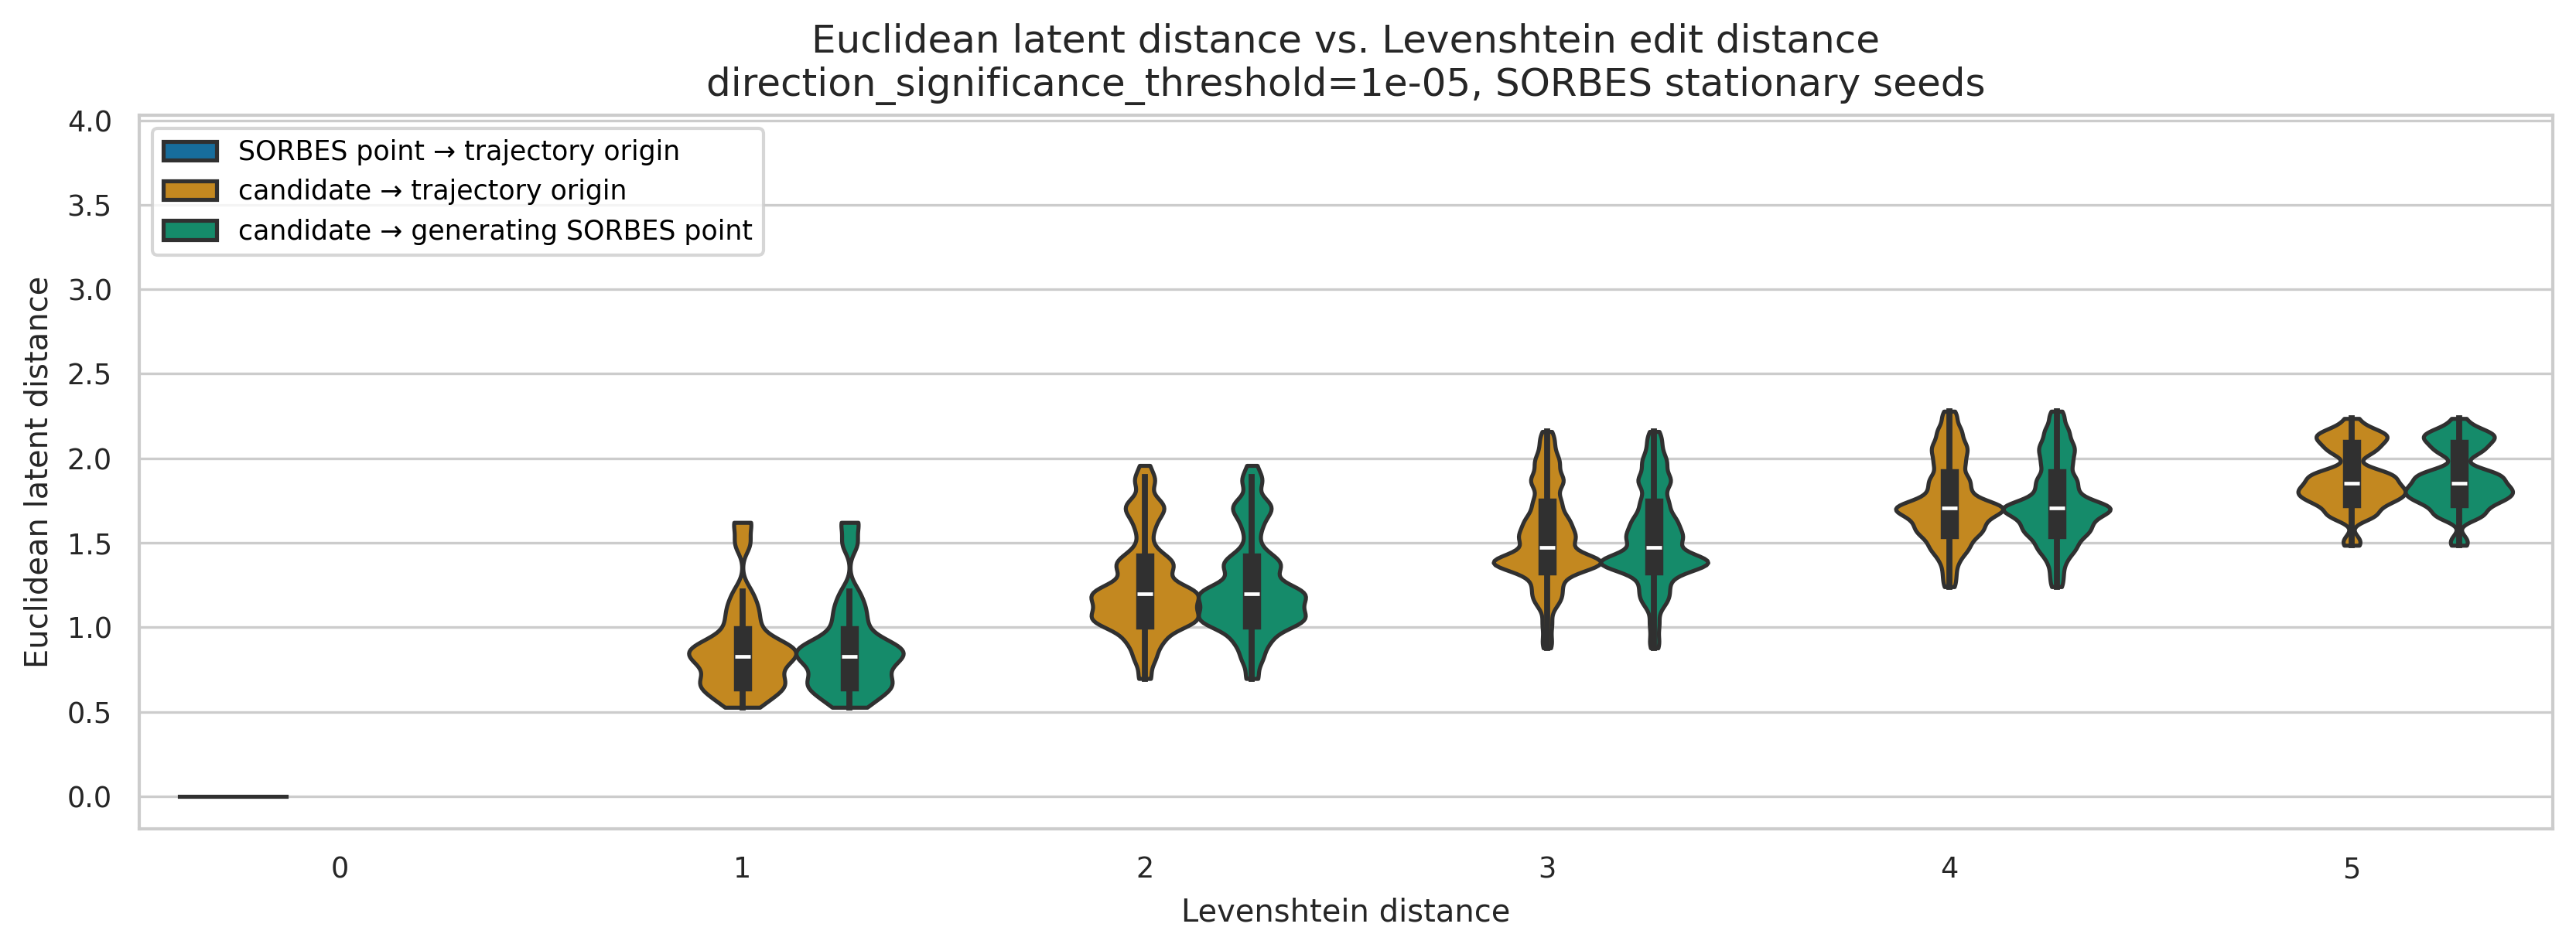

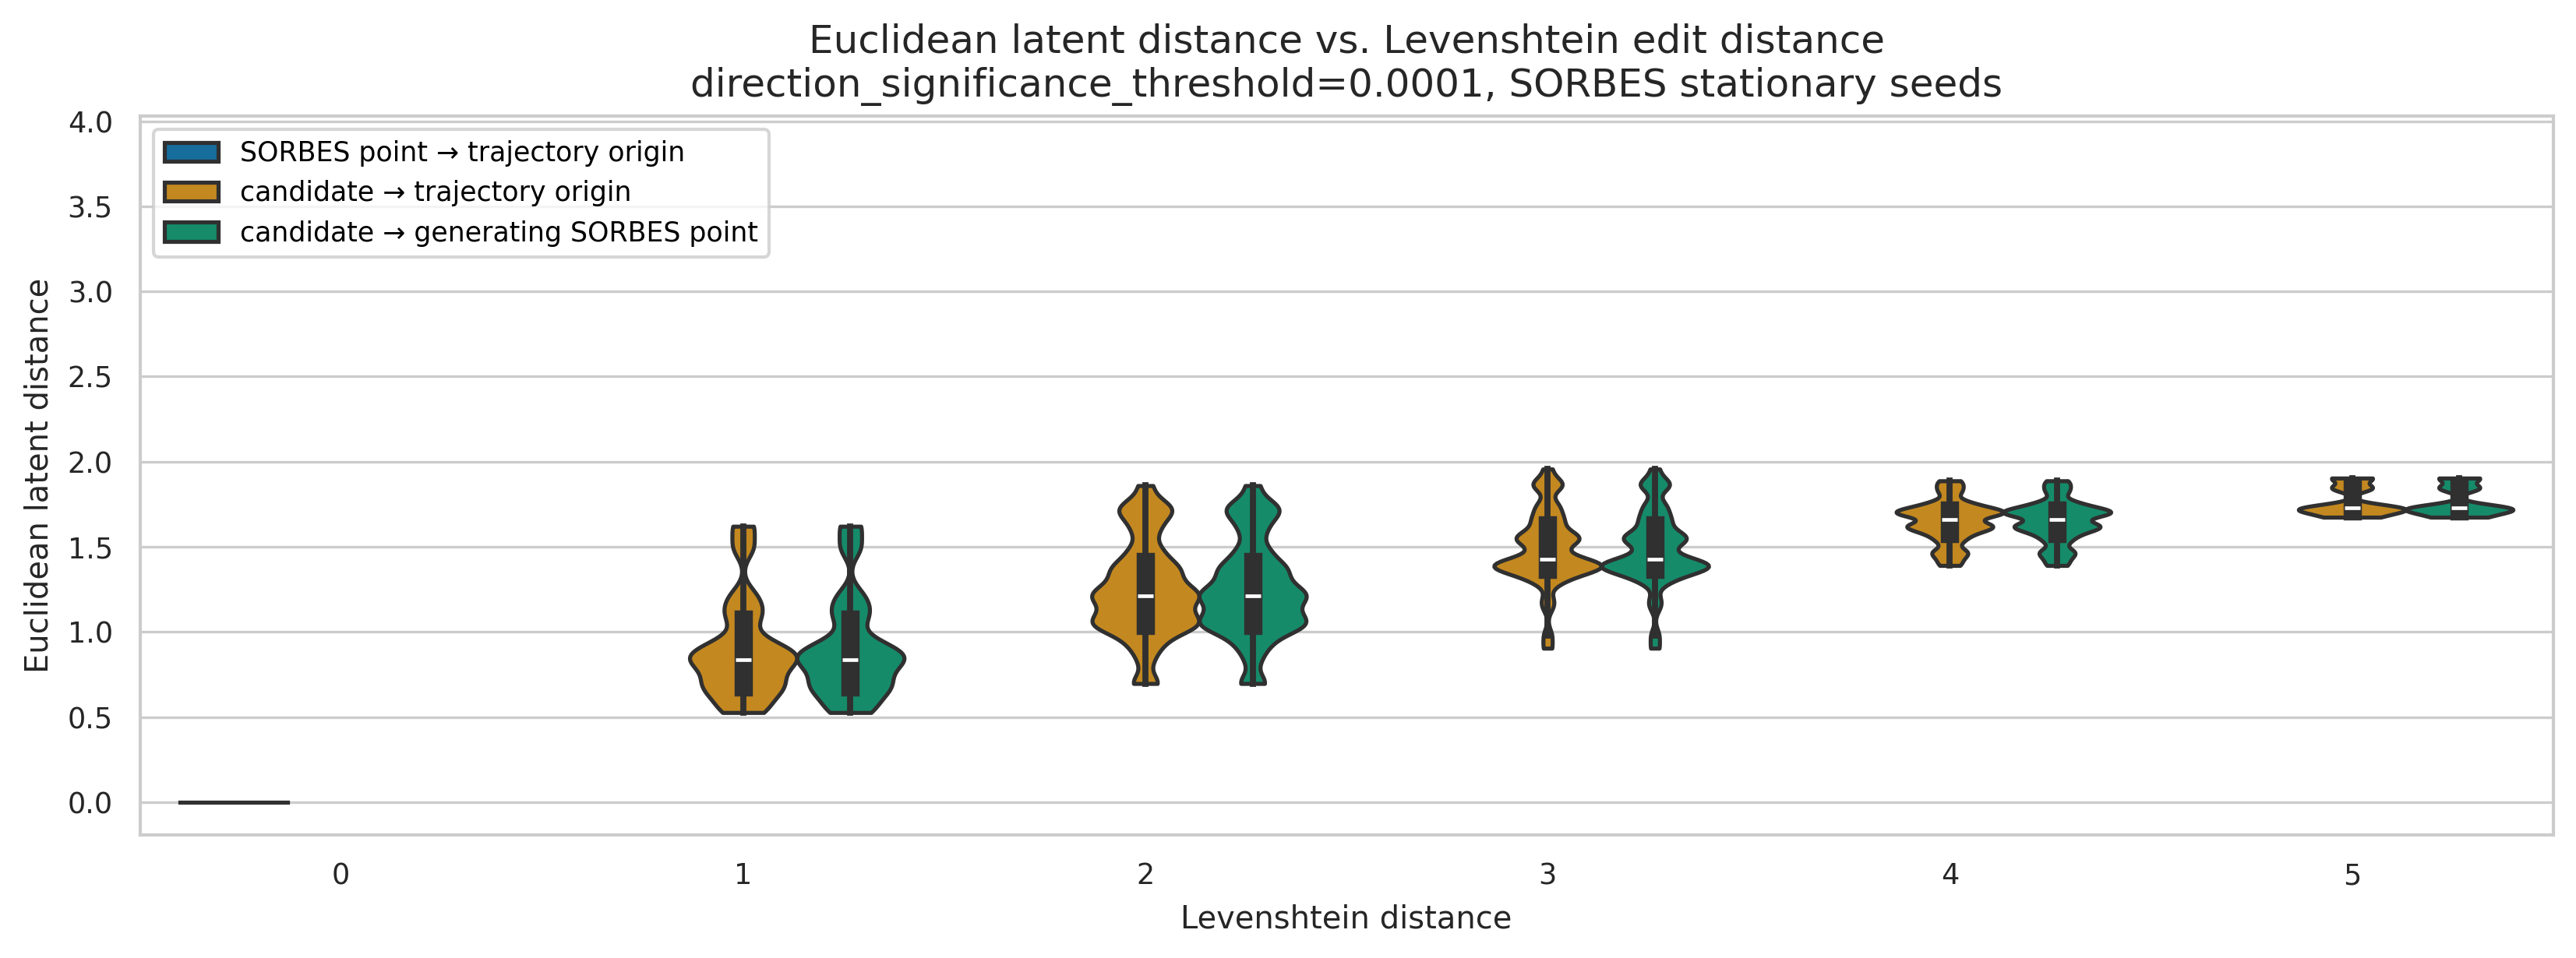

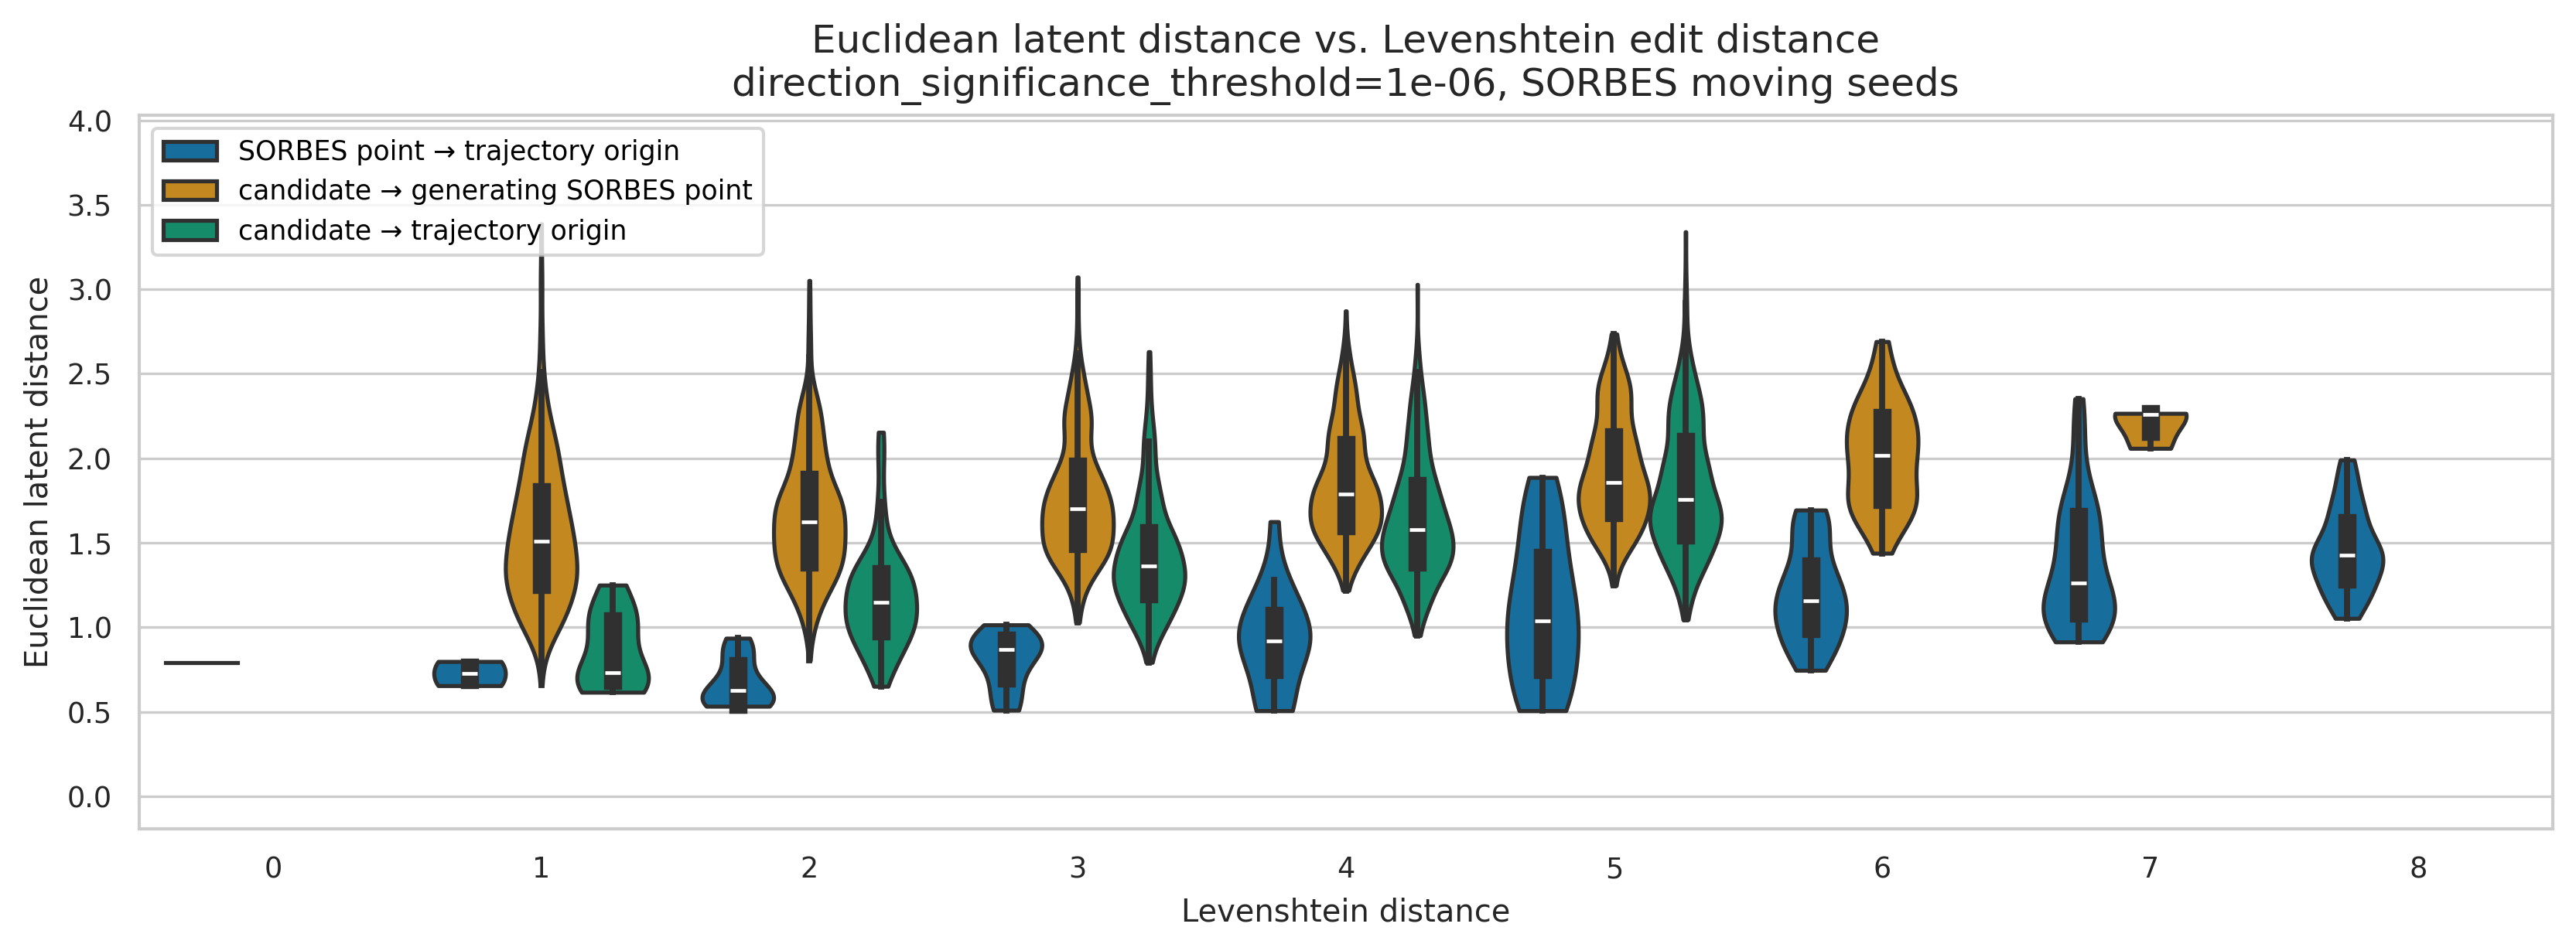

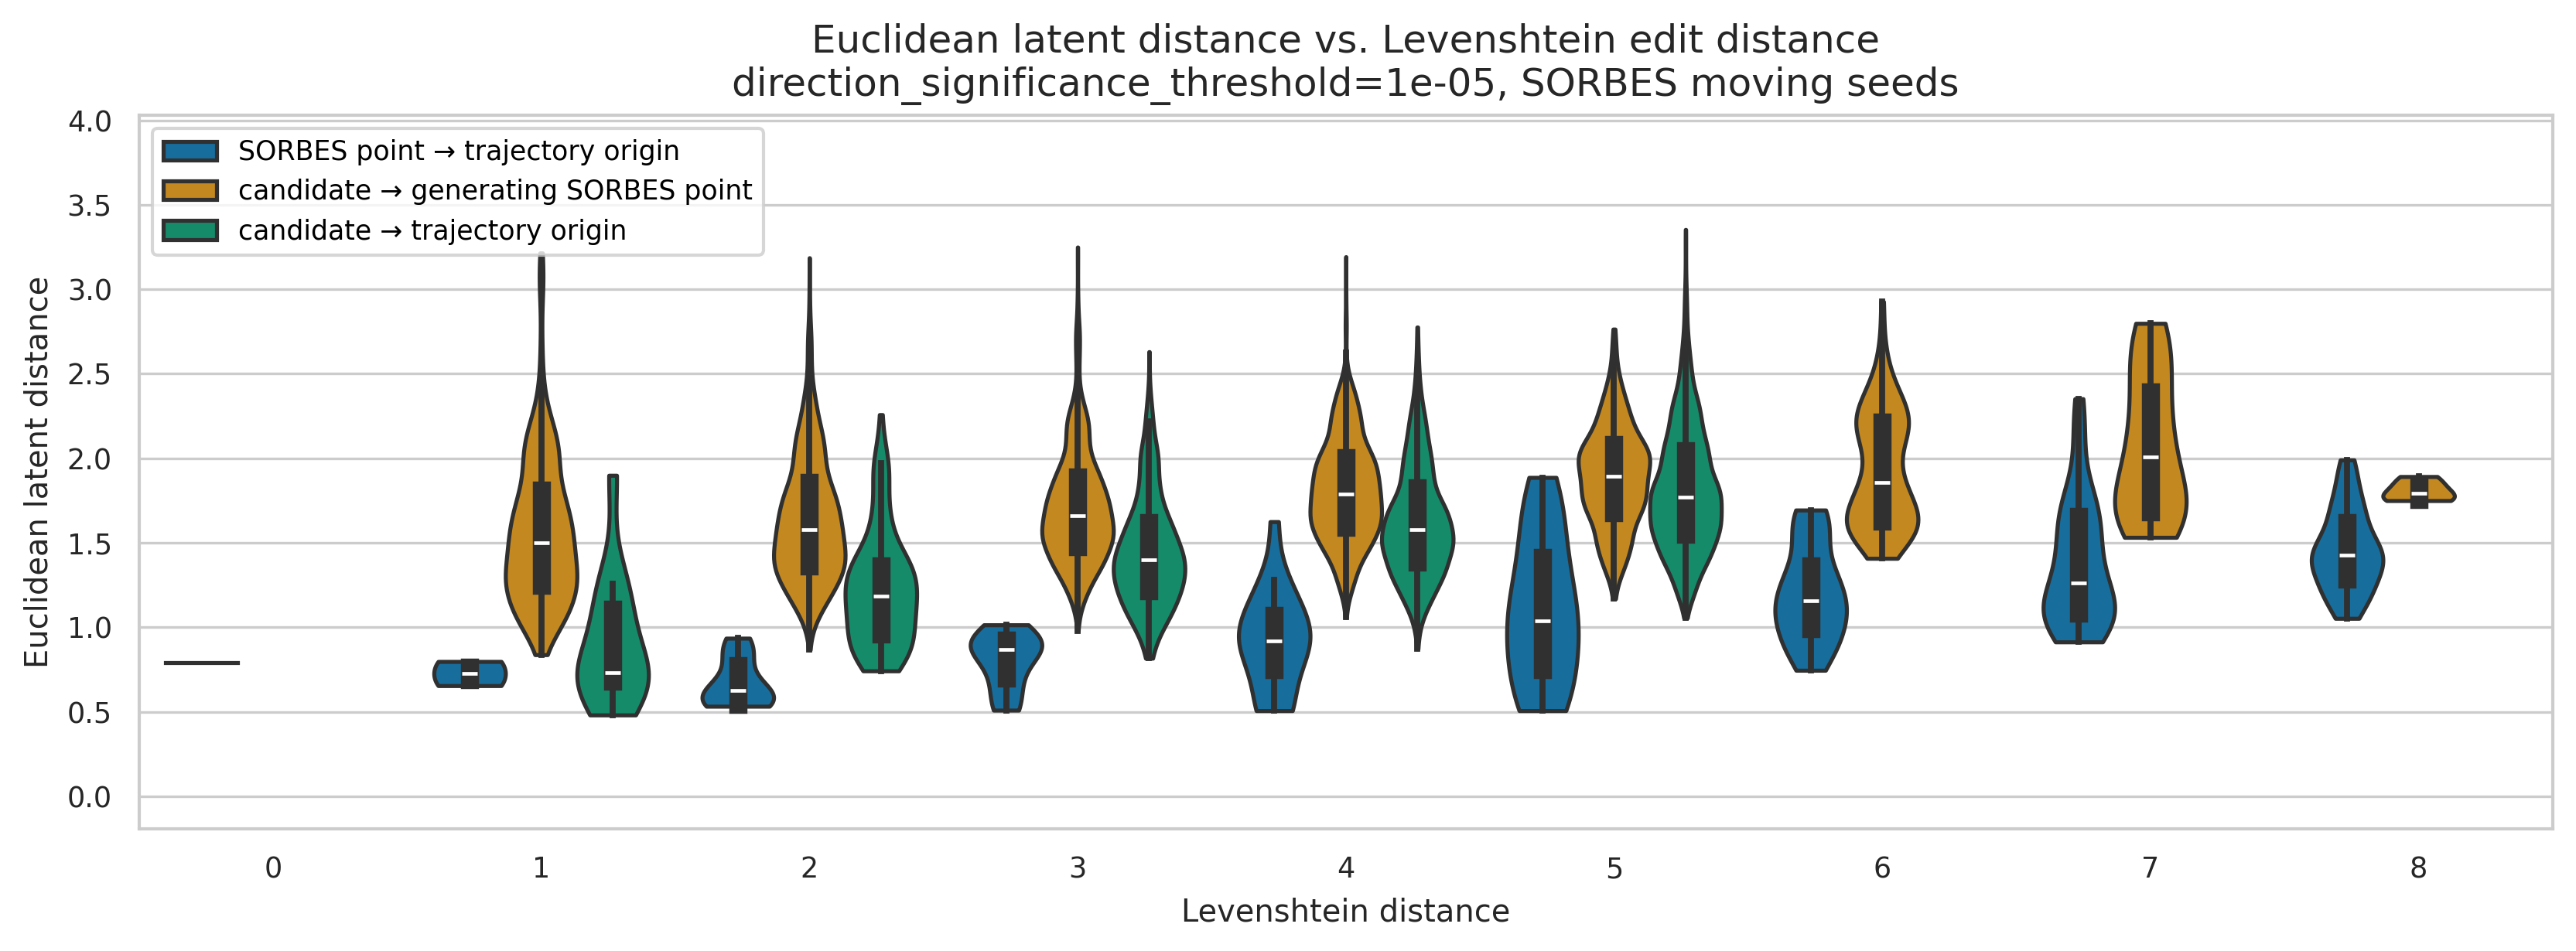

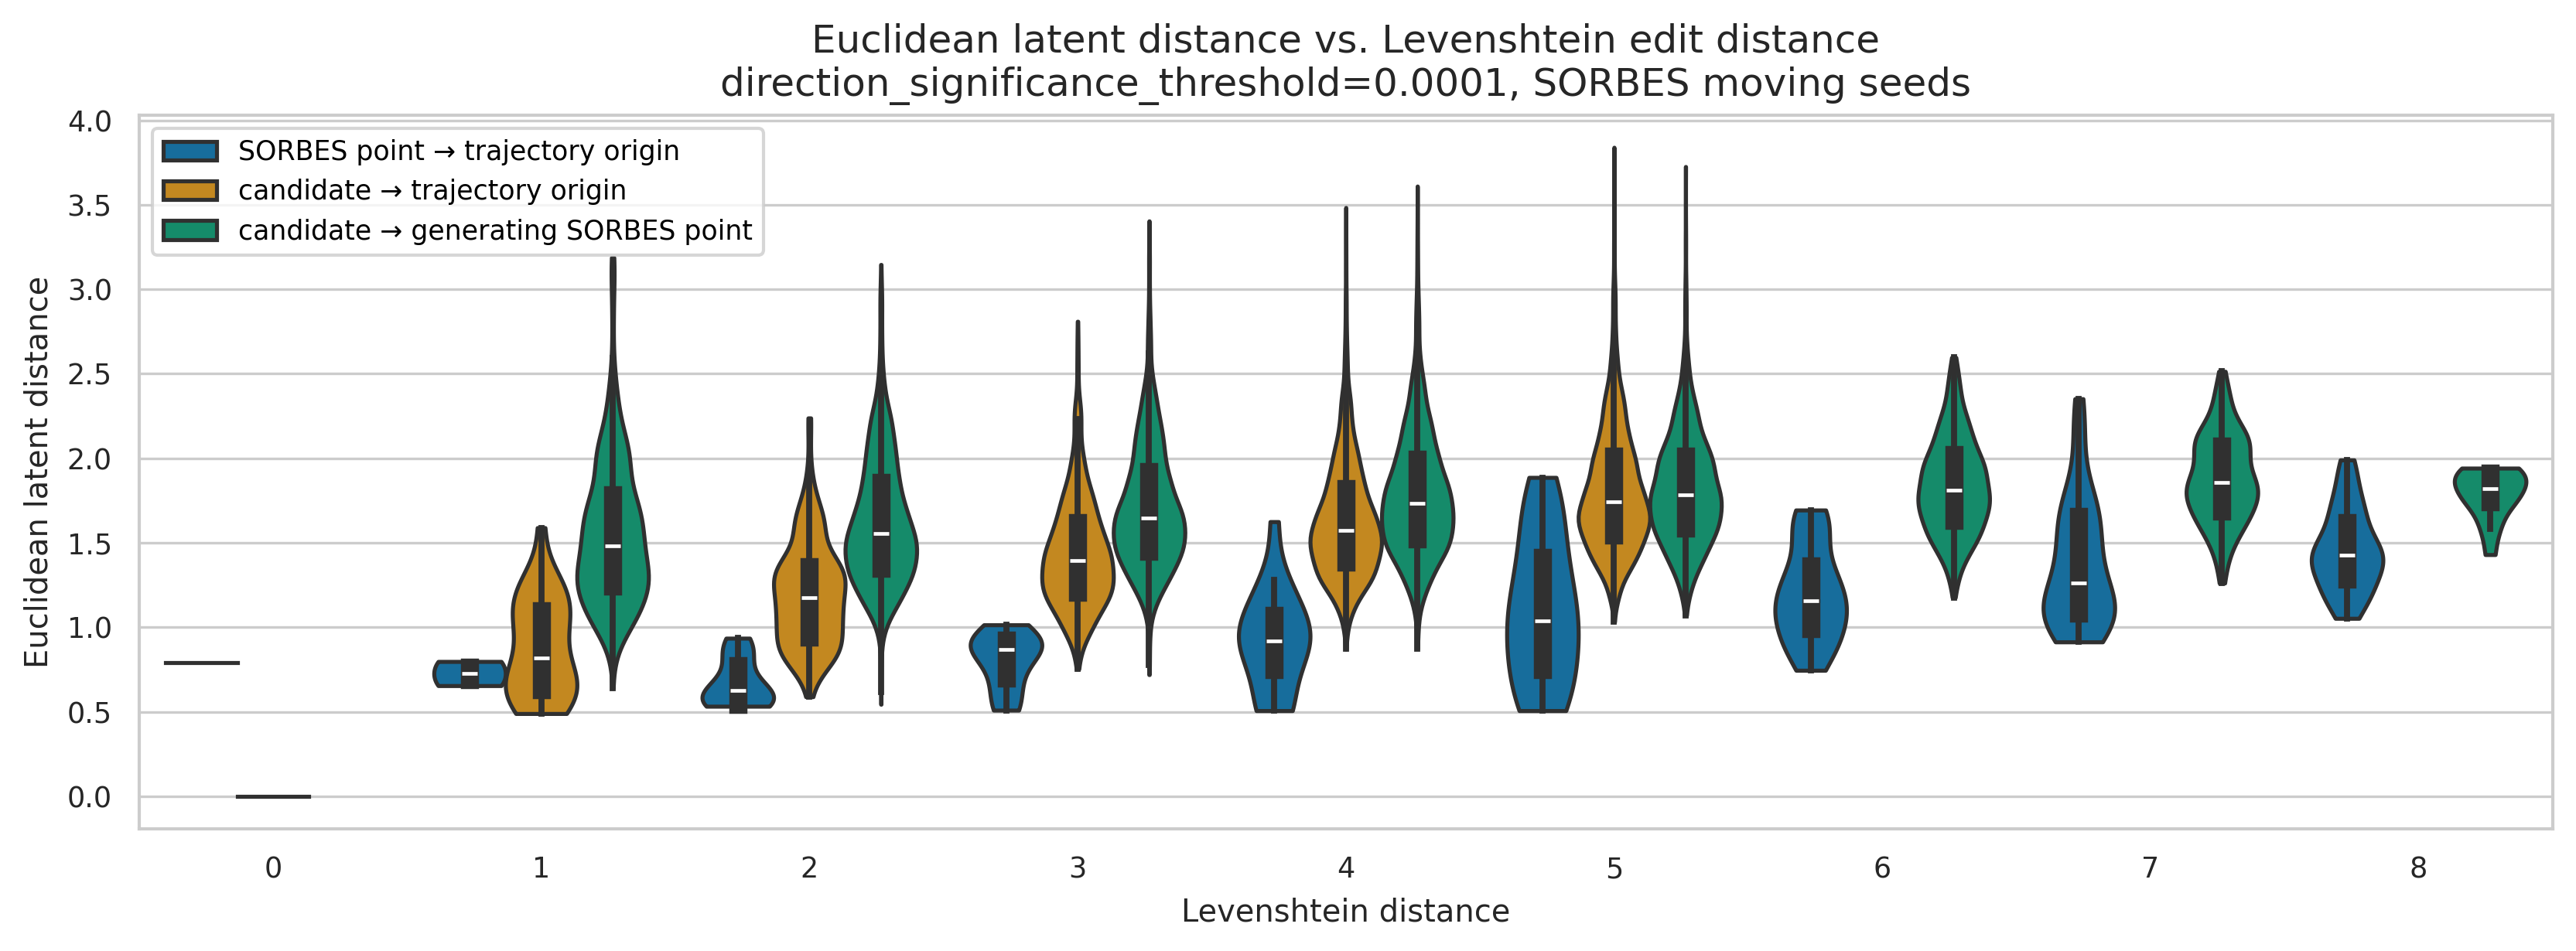

In [9]:
figures = analysis.visualize.locality.latent_jump(result)
analysis.visualize.locality.share_y_limits(figures)
for (sorbes_moved, grid_value), axes in figures.items():
    display(axes.figure)
    plt.close(axes.figure)


**Wniosek:** 6 wykresów = 2 grupy (`sorbes_moved`) x 3 warianty gridu, posortowane grupami (najpierw stationary, potem moving) -- nie przeplatane. `stationary`: pomarańczowy i zielony pokrywają się idealnie (SORBES parent = origin, ten sam wektor). `moving`: pomarańczowy (candidate -> SORBES parent) wyraźnie wyżej niż zielony (candidate -> origin) na każdym binie -- bo SORBES parent sam już odjechał od origin, więc odległość od niego to dryf SORBES + skok mutacji, a odległość od origin to tylko wypadkowe przemieszczenie.

Dlaczego niebieski (`sorbes_to_origin`) rośnie z levenshteinem, mimo że filtr levenshtein=5 SORBES-a nie dotyczy: to nie jest efekt filtra ani zależność sztuczna z binowania. Każdy punkt SORBES ma swój WŁASNY levenshtein i swój WŁASNY dystans euklidesowy -- grupowanie po levenshteinie to po prostu statystyka warunkowa: punkty, które przeszły dalej w latencie, częściej też przekraczają więcej granic decyzyjnych dekodera, więc mają większy edit distance. To realna korelacja (widoczna wprost na wykresie profilu wyżej: dystans rośnie z iteracją), a biny 6/7/8 to prawdziwe, niefiltrowane punkty SORBES z późniejszych iteracji grupy `moving`, które faktycznie osiągnęły taki edit distance.

`candidate_to_origin`/`candidate_to_sorbes_parent` ucinają się na levenshtein=5: to filtr `levenshtein` (`maximum_distance: 5`) w `local_enumeration.filters` konfiguracji runu -- dotyczy wyłącznie kandydatów MUTANG. Punkty SORBES nigdy przez ten filtr nie przechodzą (`local_enumeration.py:212` vs `:213`), stąd mogą mieć levenshtein > 5.


## Jump ratio: mało mutacji, duży skok w latencie

Metoda poniżej (`compute_outliers`) uznaje dystans za nietypowy tylko WZGLĘDEM innych obserwacji o TEJ SAMEJ wartości levenshtein_distance -- czyli duży skok przy levenshtein_distance=8, gdzie większość i tak skacze daleko, nie zostanie wychwycony, mimo że w liczbach bezwzględnych jest duży. To nie do końca odpowiada na "mało mutacji, duży skok" -- to raczej "duży jak na tę konkretną liczbę mutacji", czyli słabsze pytanie.

Tutaj zamiast tego liczę wprost `euclidean_distance / levenshtein_distance` dla każdego wiersza, tylko dla `candidate_to_sorbes_parent` (czyli skok wywołany WYŁĄCZNIE mutacją zastosowaną w tym jednym kroku -- `candidate_to_origin` dolicza też to, jak daleko sam SORBES wcześniej odjechał, co nie jest winą mutacji). Im wyższy wynik tego dzielenia, tym więcej przesunięcia w latencie przypada na pojedynczą edycję sekwencji.


In [10]:
from pep_compass.analysis.analysis_types.locality.latent_jump import rank_by_jump_ratio

ranked_jumps = rank_by_jump_ratio(result.data)

# Sortowanie globalnie po jump_ratio faworyzuje levenshtein_distance=1 (dzielenie
# przez 1 nic nie zmniejsza licznika, więc wiersze z levenshtein_distance=1 zawsze
# wygrywają) -- sprawdzone osobno: top 100 wierszy posortowanych globalnie to w 100%
# levenshtein_distance=1. Dlatego biorę top-5 OSOBNO dla każdej wartości
# levenshtein_distance (1, 2, 3, ..., 8), żeby wartości były ze sobą porównywalne.
top_per_value = (
    ranked_jumps.sort_values("euclidean_distance", ascending=False)
    .groupby("levenshtein_distance")
    .head(5)
    .sort_values(["levenshtein_distance", "euclidean_distance"], ascending=[True, False])
)
display(
    top_per_value[
        ["levenshtein_distance", "euclidean_distance", "jump_ratio", "run_id", "grid_value", "sorbes_moved", "sequence"]
    ]
)


,levenshtein_distance,euclidean_distance,jump_ratio,run_id,grid_value,sorbes_moved,sequence
0,1,3.387788,3.387788,run_00003,0.000001,True,KKYRLIYKWIRLRF
1,1,3.215288,3.215288,run_00009,0.000010,True,KKYRLIRKWIRLRY
2,1,3.187954,3.187954,run_00015,0.000100,True,KKFRLIRKWIRLRF
3,1,3.160980,3.160980,run_00009,0.000010,True,KKYRLIQKWIRLRF
4,1,3.160980,3.160980,run_00015,0.000100,True,KKYRLIQKWIRLRF
766,2,3.186611,1.593306,run_00009,0.000010,True,KKYRLIRWWHRLWFG
777,2,3.146844,1.573422,run_00015,0.000100,True,WKYWLIRKWIRLWISI
825,2,3.075443,1.537721,run_00015,0.000100,True,KKYRLIRPWIREWPGT
842,2,3.052468,1.526234,run_00003,0.000001,True,KKYRLIYKWIRLWF
868,2,3.003150,1.501575,run_00015,0.000100,True,KKYRLIRKWIRLQP


**Wniosek:** maksymalny bezwzględny skok jest w zasadzie tego samego rzędu dla levenshtein_distance 1-5 (~3.0-3.7), a spada dopiero przy 6-8 (~1.9-2.9) -- czyli **pojedyncza mutacja potrafi wywołać niemal taki sam skok w latencie jak pięć mutacji naraz**. `jump_ratio` (skok na jedną edycję) maleje monotonicznie w miarę wzrostu levenshtein_distance: 3.39 -> 1.59 -> 1.13 -> 0.90 -> 0.75 -> 0.49 -> 0.40 -> 0.24 -- więc tak, te przypadki "mało mutacji, duży skok w latencie" realnie występują, najsilniej przy levenshtein_distance=1-2. Przy levenshtein_distance 1-5 dominują `run_00015`/`run_00009`/`run_00003`, przy 6-8 dominują `run_00008`/`run_00014` -- czyli inne runy odpowiadają za duże skoki przy małej liczbie mutacji niż przy dużej.


## Outliers

Jak to jest liczone, krok po kroku:

1. Dzielę wszystkie obserwacje na osobne grupy. Jedna grupa = jedna konkretna kombinacja trzech rzeczy: rodzaj dystansu (candidate_to_origin / candidate_to_sorbes_parent / sorbes_to_origin), konkretna wartość progu `direction_significance_threshold` (1e-6 / 1e-5 / 1e-4 -- parametr MUTANGa przeszukiwany w trzech wariantach), i konkretna wartość `levenshtein_distance` (0, 1, 2, ..., 8 -- liczba różniących się aminokwasów).
2. W KAŻDEJ takiej grupie osobno liczę Q1 (wartość, poniżej której jest 25% obserwacji w tej grupie) i Q3 (poniżej której jest 75%) dystansu euklidesowego.
3. Próg dla tej grupy = Q3 + 3 x (Q3 - Q1).
4. Obserwacja jest outlierem, jeśli JEJ WŁASNY dystans euklidesowy przekracza TEN próg policzony w JEJ WŁASNEJ grupie -- czyli porównanie tylko do innych obserwacji o tym samym rodzaju dystansu, tym samym progu MUTANGa i tej samej liczbie różniących się aminokwasów, nie do wszystkich obserwacji naraz.

Przykład (pierwszy wiersz tabeli poniżej): `run_00015, grid_value=0.0001, distance_kind=candidate_to_origin, levenshtein_distance=5, euclidean_distance=3.84`. Czytamy to tak: ten kandydat różni się od sekwencji startowej o 5 aminokwasów, a jego prawdziwy (przeliczony na nowo) latent leży 3.84 od latentu startowego -- podczas gdy próg dla tej konkretnej grupy (levenshtein_distance=5, ten sam grid, ten sam rodzaj dystansu) wynosi mniej. Czyli: umiarkowana liczba mutacji, ale nietypowo duży skok w przestrzeni latentnej względem innych kandydatów z tą samą liczbą mutacji.


In [11]:
from pep_compass.analysis.analysis_types.locality.latent_jump import compute_outliers

# Recomputed from result.data directly (cheap: pandas groupby, no autoencoder)
# rather than read from result.diagnostics, since diagnostics are not persisted
# by the analysis cache and would be empty on a cache hit.
outliers, frequency = compute_outliers(result.data)

print(f"{len(outliers)} outliers out of {len(result.data)} observations")
display(outliers.head(30))

display(
    frequency.pivot_table(
        index=["distance_kind", "levenshtein_distance"],
        columns="grid_value",
        values="outlier_fraction",
    )
)


245 outliers out of 254556 observations


,run_id,grid_value,sorbes_moved,distance_kind,trajectory_step,levenshtein_distance,euclidean_distance,sequence
0,run_00015,0.000100,True,candidate_to_origin,5,5,3.840580,KKYRLIRKRIRDWPGT
1,run_00015,0.000100,True,candidate_to_sorbes_parent,5,5,3.726496,KKYRLIRKRIRDWPGT
2,run_00015,0.000100,True,candidate_to_origin,5,5,3.700149,KKYRLIRKRIREWPGT
3,run_00015,0.000100,True,candidate_to_sorbes_parent,5,4,3.610862,KKYRLIRKRIREWPGT
4,run_00015,0.000100,True,candidate_to_origin,5,5,3.526663,KKYRLIRKRIRDWPVT
5,run_00015,0.000100,True,candidate_to_origin,5,5,3.516395,KKYRLIRKWIQDWPGT
6,run_00015,0.000100,True,candidate_to_origin,5,4,3.484075,KKYRLIRKWIRDWPGT
7,run_00015,0.000100,True,candidate_to_origin,1,5,3.483672,WKRWLIRKWIRLWISI
8,run_00015,0.000100,True,candidate_to_origin,1,5,3.473864,WKRWLIRKWIRLWISP
9,run_00015,0.000100,True,candidate_to_sorbes_parent,5,4,3.466158,KKYRLIRKRIRDWPVT


grid_value                                       0.000001  0.000010  0.000100
distance_kind              levenshtein_distance                              
candidate_to_origin        0                          NaN       NaN  0.000000
                           1                     0.003472  0.000431  0.000000
                           2                     0.000000  0.000000  0.000000
                           3                     0.000000  0.000000  0.001393
                           4                     0.000000  0.000000  0.007670
                           5                     0.000000  0.000739  0.002355
candidate_to_sorbes_parent 1                     0.002080  0.004788  0.004098
                           2                     0.000169  0.001086  0.000331
                           3                     0.000000  0.000392  0.003816
                           4                     0.000000  0.000190  0.011618
                           5                     0.000000  0.000000  0.006664
                           6                     0.000000  0.000000  0.000000
                           7                     0.000000  0.000000  0.000000
                           8                          NaN  0.000000  0.000000
sorbes_to_origin           0                     0.003322  0.003322  0.003322
                           1                     0.000000  0.000000  0.000000
                           2                     0.000000  0.000000  0.000000
                           3                     0.000000  0.000000  0.000000
                           4                     0.000000  0.000000  0.000000
                           5                     0.000000  0.000000  0.000000
                           6                     0.000000  0.000000  0.000000
                           7                     0.000000  0.000000  0.000000
                           8                     0.000000  0.000000  0.000000

### Konkretne rozbicie: ile outlierów, dokładnie skąd

`frequency`/`outlier_fraction` powyżej pokazuje ODSETEK per grupa -- tu jest surowa LICZBA, rozbita na kilka sposobów naraz, żeby było jasne skąd te 245 się bierze.


In [12]:
print(f"RAZEM: {len(outliers)} outlierów na {len(result.data)} obserwacji ({100 * len(outliers) / len(result.data):.3f}%)")
print()
print("ile outlierów przypada na każdy rodzaj dystansu:")
print(outliers["distance_kind"].value_counts())
print()
print("ile outlierów przypada na 'sorbes się ruszał' vs 'sorbes stał w miejscu':")
print(outliers["sorbes_moved"].value_counts())
print()
print("ile outlierów przypada na każdą wartość progu direction_significance_threshold:")
print(outliers["grid_value"].value_counts())
print()
print("ile outlierów przypada na każdy run (tylko te, które mają choć jeden):")
print(outliers["run_id"].value_counts())


RAZEM: 245 outlierów na 254556 obserwacji (0.096%)

ile outlierów przypada na każdy rodzaj dystansu:
distance_kind
candidate_to_sorbes_parent    161
candidate_to_origin            81
sorbes_to_origin                3
Name: count, dtype: int64

ile outlierów przypada na 'sorbes się ruszał' vs 'sorbes stał w miejscu':
sorbes_moved
True     241
False      4
Name: count, dtype: int64

ile outlierów przypada na każdą wartość progu direction_significance_threshold:
grid_value
0.000100    200
0.000010     36
0.000001      9
Name: count, dtype: int64

ile outlierów przypada na każdy run (tylko te, które mają choć jeden):
run_id
run_00015    189
run_00009     31
run_00014     11
run_00008      5
run_00003      4
run_00000      4
run_00002      1
Name: count, dtype: int64


**Wniosek:** 245 outlierów na 254 556 obserwacji, czyli 0.096% -- rzeczywiście mało. Skąd dokładnie:

- rodzaj dystansu: candidate_to_sorbes_parent = 161, candidate_to_origin = 81, sorbes_to_origin = tylko 3
- ruch SORBES: 241 z grupy, gdzie SORBES się ruszał, tylko 4 z grupy, gdzie stał w miejscu
- próg direction_significance_threshold: 200 przy 1e-4, 36 przy 1e-5, 9 przy 1e-6 -- im mniej restrykcyjny próg, tym więcej outlierów
- pojedynczy run: `run_00015` sam odpowiada za 189 z 245 (77%)

Czyli outliery to prawie wyłącznie kandydaci (nie punkty SORBES), prawie wyłącznie tam gdzie SORBES faktycznie się ruszał, mocno skoncentrowane w jednym runie przy najmniej restrykcyjnym progu.


# Lokalność grup peptydów w przestrzeni HydrAMP

Nowa, osobna analiza -- nie dotyczy eksperymentów SORBES/MUTANG powyżej, tylko surowego zbioru treningowego HydrAMP (`assets/peptides_data/peptides.csv`, 305 164 peptydów).

Grupy = biologiczny warunek treningowy HydrAMP $c=(c_{AMP}, c_{MIC})$, nie surowa kolumna `dataset` (ta ostatnia to nazwy plików źródłowych typu `hydramp_uniprot_0_25_val` -- podział train/val/test albo pojedyncza baza danych, nie kategoria biologiczna). Zweryfikowane wprost w Methods artykułu HydrAMP (`tmp/hydraamp.pdf`) i w oficjalnym repo (`szczurek-lab/hydramp`, `scripts/dataset_preparation.ipynb`):

- **AMP_high_MIC** ($c=1,1$): potwierdzone AMP z DBAASP, MIC <= 32 ug/mL vs. *E. coli* (tag `hydramp_dbaasp_high_ecoli_activity`) -- 809 peptydów.
- **AMP_low_MIC** ($c=1,0$): potwierdzone AMP z DBAASP, MIC > 32 ug/mL vs. *E. coli* (tag `hydramp_dbaasp_low_ecoli_activity`) -- 366 peptydów.
- **non_AMP** ($c=0,0$): potwierdzone tło bez aktywności (podziały UniProt `hydramp_uniprot_0_25_train/val/test` + `hydramp_veltri_negative`) -- 226 084 peptydów.

$c=(0,1)$ nie jest biologicznie spójne (MIC ma sens tylko dla potwierdzonego AMP) i nie występuje. Pominięte: `ampsphere_amp` (73 558 peptydów -- osobna, dużo większa baza AMP niż te 11 131, na których trenowano HydrAMP, nie umiem jej pewnie zmapować), `hydramp_dbaasp_clean`/`hydramp_mic_data`/`hydramp_veltri_positive` bez rozstrzygniętego progu MIC vs *E. coli*, oraz tagi `_saureus_activity` (zła bakteria -- warunek MIC w papierze jest zdefiniowany tylko dla *E. coli*).

Dla każdej grupy, w przestrzeni latentnej (`z = mu_phi(s)`):
1. dla próbki peptydów z grupy -- dystans do 100 najbliższych sąsiadów W TEJ SAMEJ grupie (lokalna gęstość),
2. dla wszystkich peptydów w grupie -- dystans do centroidu grupy, czyli średniej wszystkich wektorów latentnych w grupie (jak bardzo grupa jest rozstrzelona).

To na razie czysta diagnostyka -- nie BLOSUM, nie testy statystyczne. Liczone na GPU.

**Ważne (z artykułu):** HydrAMP był explicite regularyzowany tak, żeby $z$ NIE kodowało bezpośrednio $c_{AMP}$/$c_{MIC}$ (Jacobian disentanglement) -- więc nakładanie się tych grup w $z$ jest zgodne z celem modelu, nie jest automatycznie oznaką błędu. To poniżej służy do porównania lokalnych odległości, nie do testowania czy grupy tworzą odseparowane klastry.


In [4]:
from pep_compass.analysis.analysis_types.peptide_space import group_locality, load_amp_mic_groups
from pep_compass.analysis.visualization import PeptideSpaceVisualizer, PlotTheme

peptides_path = REPOSITORY_ROOT / "assets/peptides_data/peptides.csv"
peptides = load_amp_mic_groups(peptides_path)
peptide_space_visualizer = PeptideSpaceVisualizer(PlotTheme.preset("paper"))

print(f"{len(peptides)} peptydów z jednoznacznie rozstrzygniętą grupą (c_AMP, c_MIC)")
display(peptides["group"].value_counts())


227259 peptydów z jednoznacznie rozstrzygniętą grupą (c_AMP, c_MIC)


group
non_AMP         226084
AMP_high_MIC       809
AMP_low_MIC        366
Name: count, dtype: int64

In [5]:
peptide_space_result_k100 = group_locality(peptides, progress=False, neighbor_sample_size=300)
display(peptide_space_result_k100.metadata)

{'analysis': 'group_locality',
 'group_count': 3,
 'group_sizes': {'AMP_high_MIC': 809, 'AMP_low_MIC': 366, 'non_AMP': 226084},
 'neighbor_count': 100,
 'neighbor_sample_size': 300,
 'model_name': 'article_25'}

/home/max/repositories/pep-compass/src/pep_compass/analysis/visualization/peptide_space.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


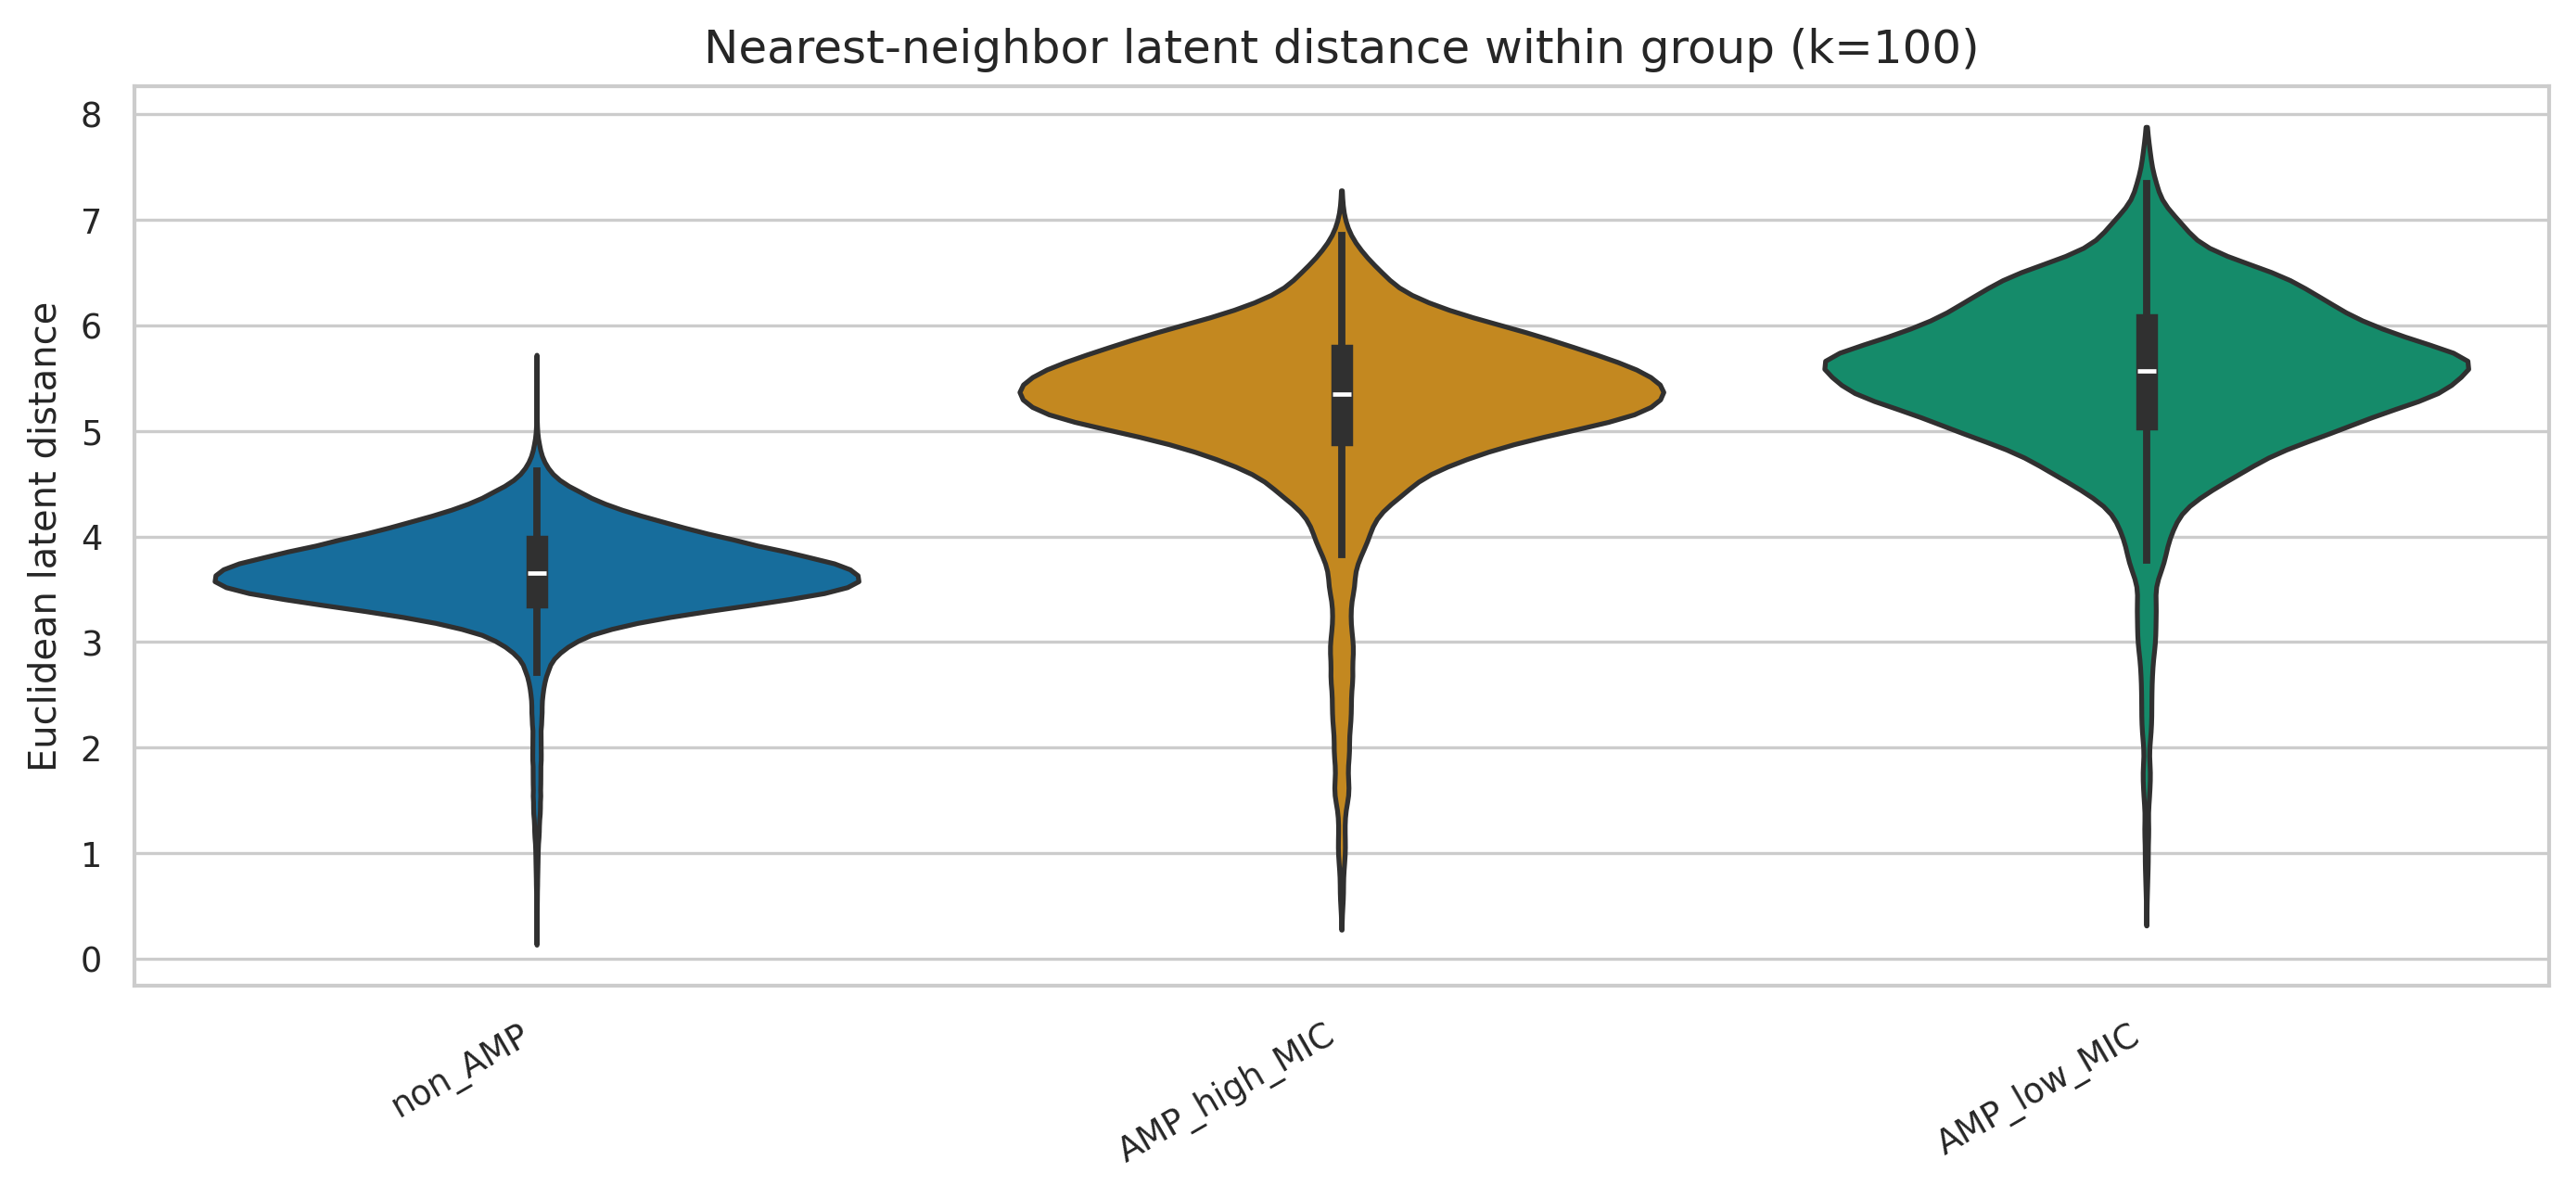

In [15]:
axes = peptide_space_visualizer.neighbor_distance(peptide_space_result_k100)
display(axes.figure)
plt.close(axes.figure)

{'analysis': 'group_locality',
 'group_count': 3,
 'group_sizes': {'AMP_high_MIC': 809, 'AMP_low_MIC': 366, 'non_AMP': 226084},
 'neighbor_count': 10,
 'neighbor_sample_size': 10000,
 'model_name': 'article_25'}

/home/max/repositories/pep-compass/src/pep_compass/analysis/visualization/peptide_space.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


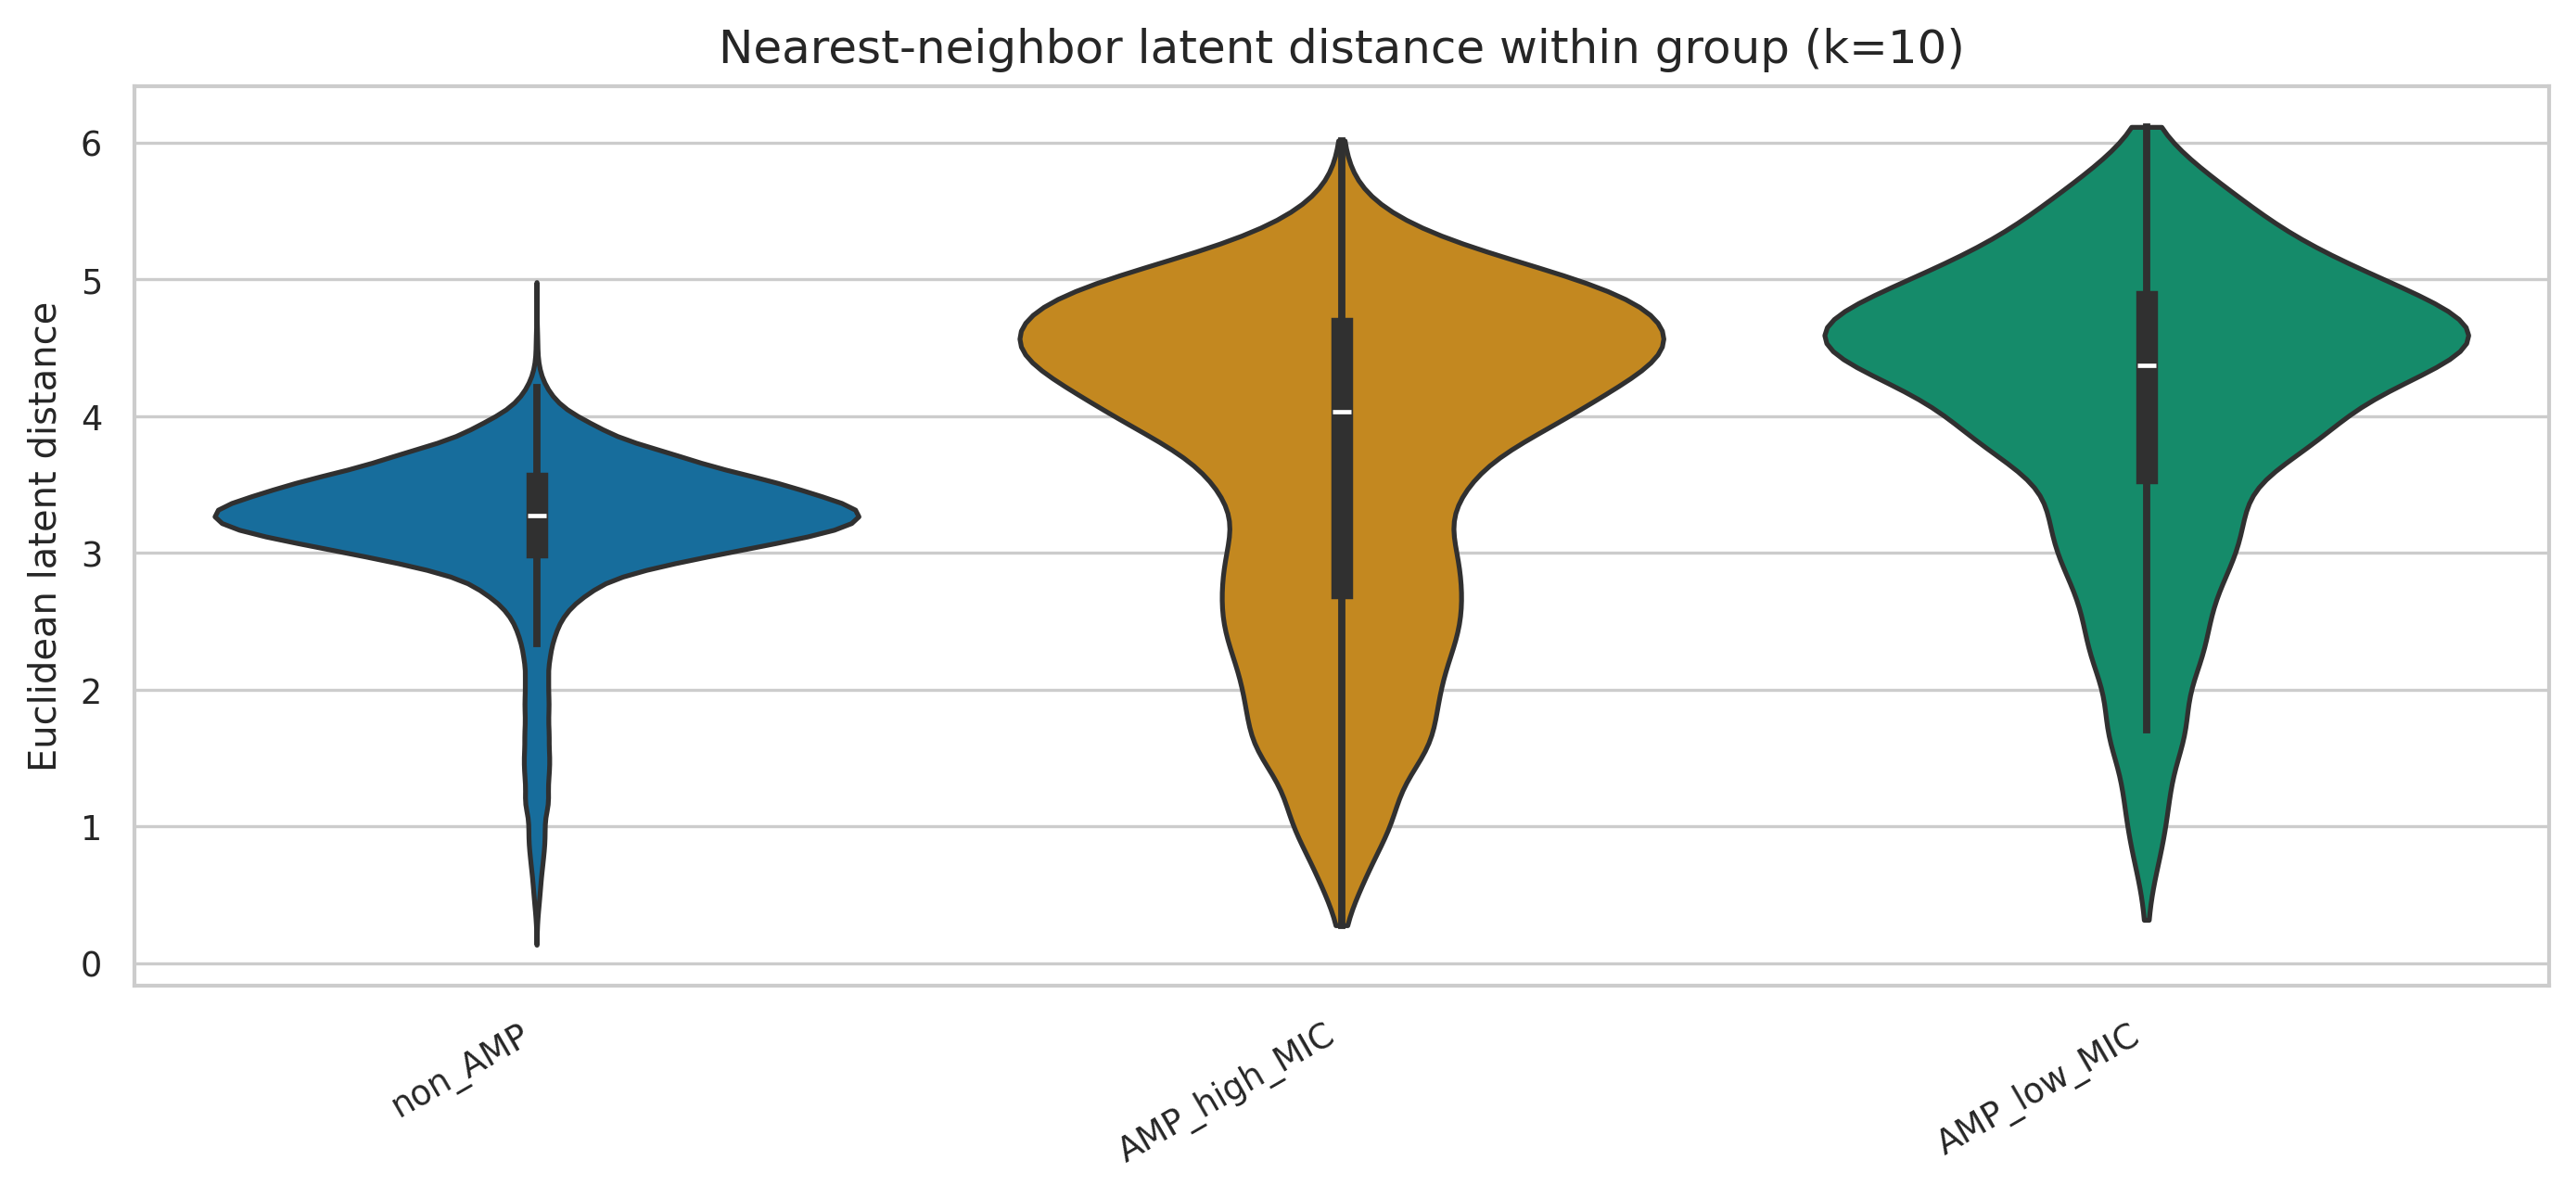

In [16]:
peptide_space_result_k10 = group_locality(peptides, progress=False, neighbor_sample_size=10_000, neighbor_count=10)
display(peptide_space_result_k10.metadata)

axes = peptide_space_visualizer.neighbor_distance(peptide_space_result_k10)
display(axes.figure)
plt.close(axes.figure)

/home/max/repositories/pep-compass/src/pep_compass/analysis/visualization/peptide_space.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


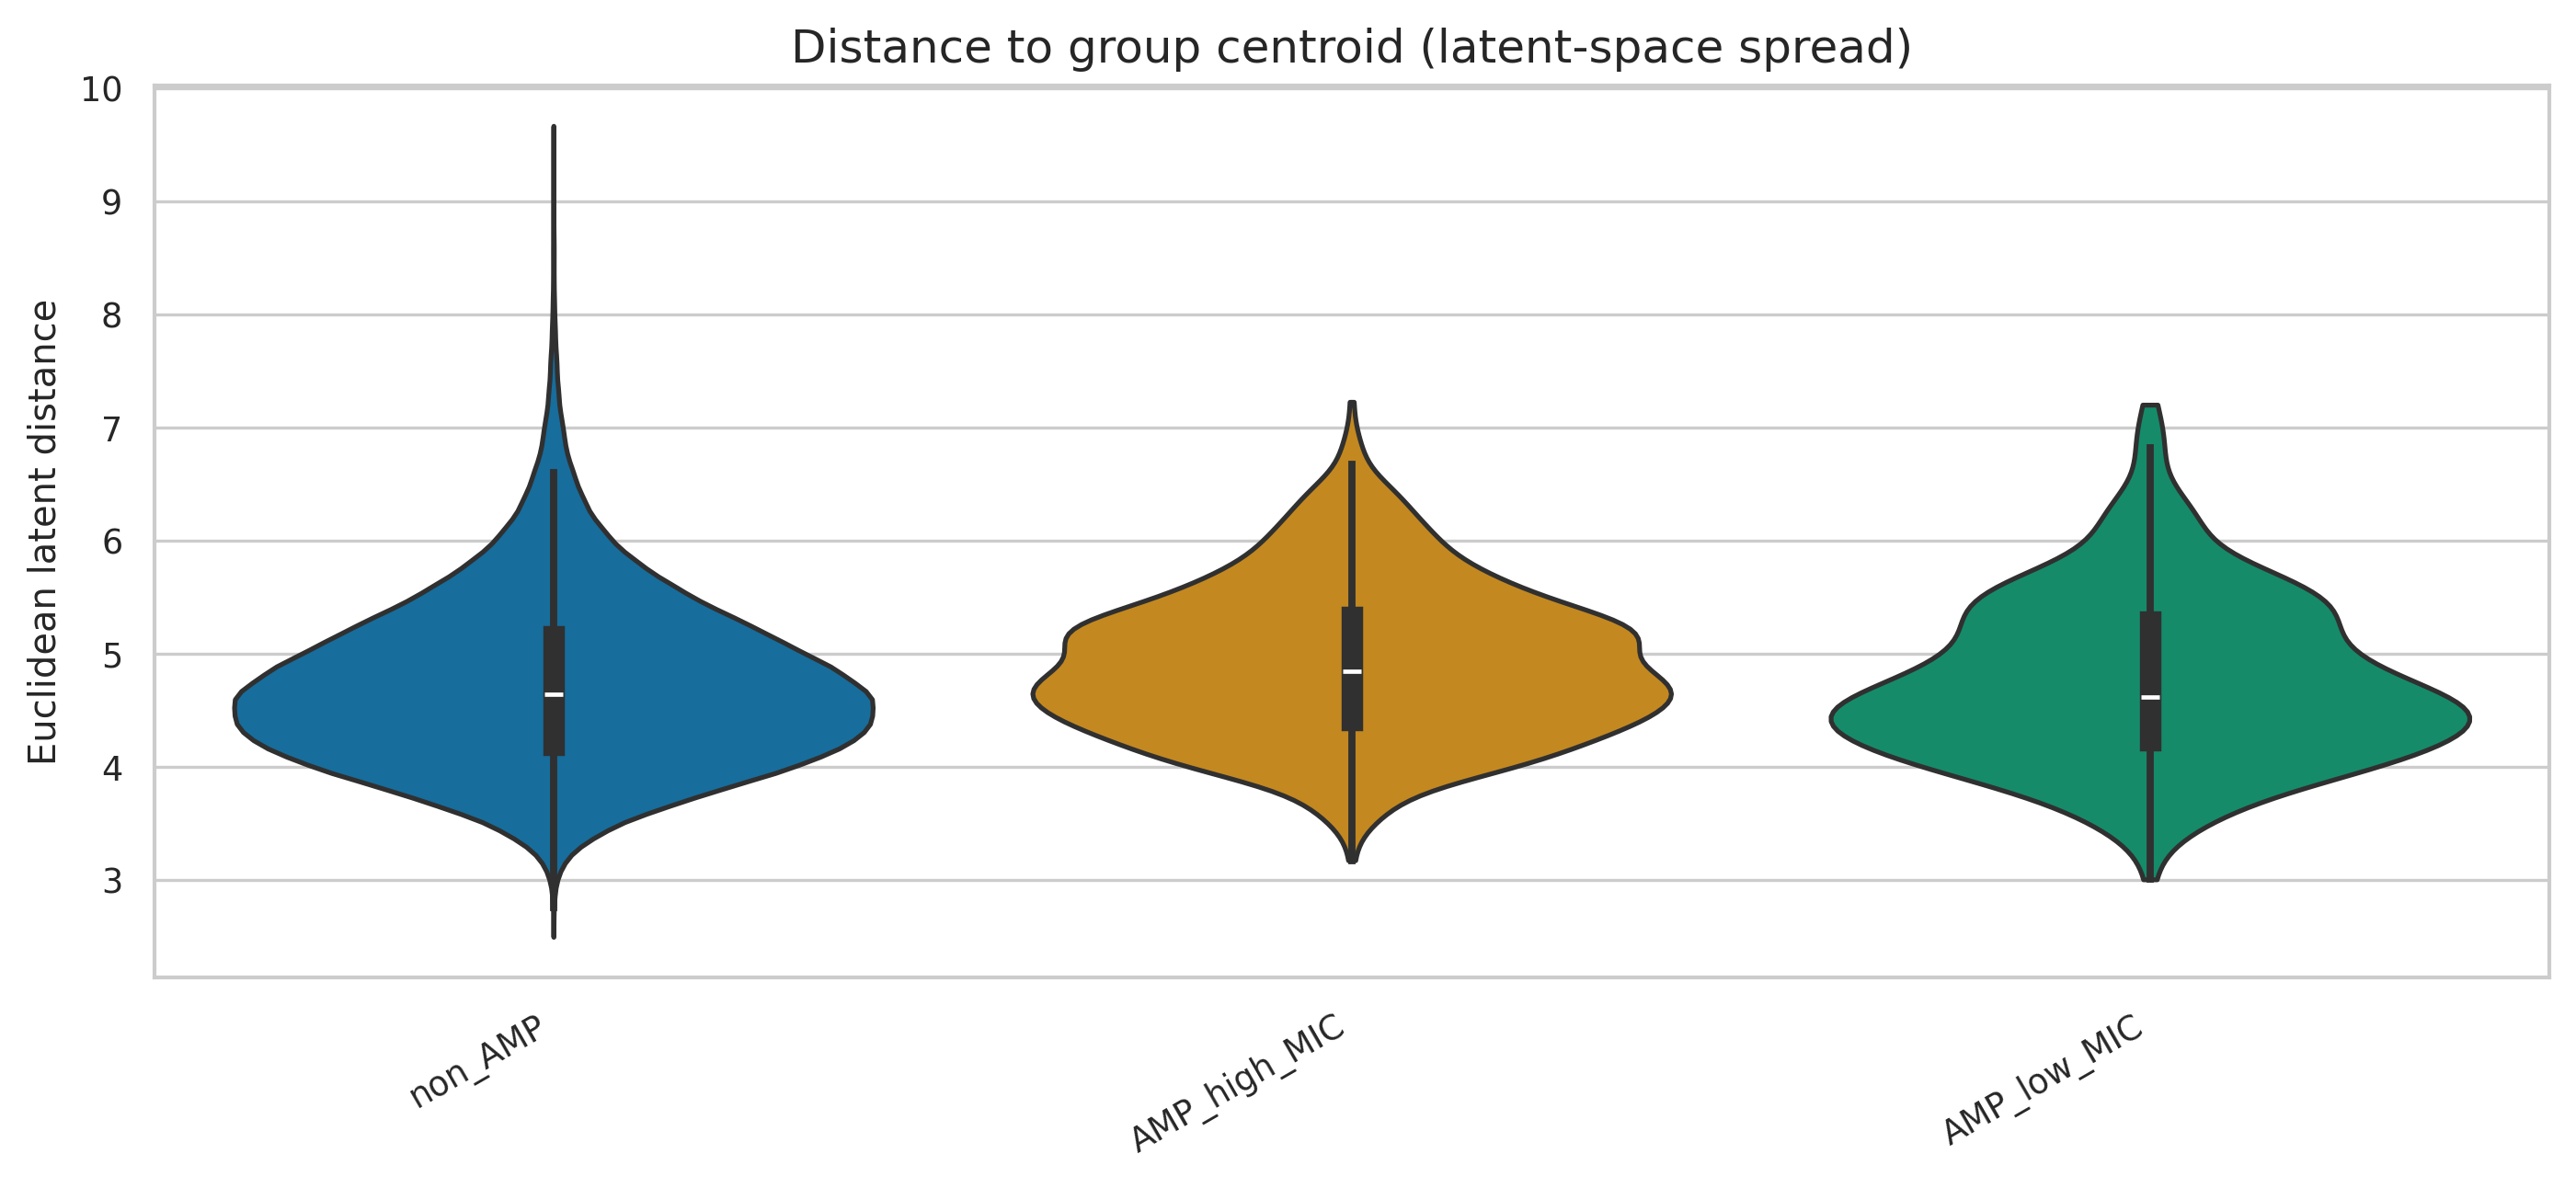

In [17]:
axes = peptide_space_visualizer.centroid_distance(peptide_space_result_k100)
display(axes.figure)
plt.close(axes.figure)

**Wniosek:** dystans wewnątrzgrupowy da się sensownie zdefiniować -- nie jest zdegenerowany (te same wartości dla wszystkich grup) ani przypadkowy.

Mediana dystansu do najbliższych sąsiadów (k=100): `AMP_low_MIC`=5.57, `AMP_high_MIC`=5.35, `non_AMP`=3.66 -- non_AMP wyraźnie niższe, ale to głównie efekt rozmiaru grupy (226 084 vs 809/366 -- więcej punktów w tej samej przestrzeni = bliżsi sąsiedzi niezależnie od tego, czy grupa jest "biologicznie zwarta").

Mediana dystansu do centroidu (ogólny rozrzut grupy) jest za to bardzo jednolita: 4.62-4.85 dla wszystkich trzech grup, różnica ~5% -- praktycznie niezależna od rozmiaru grupy, w przeciwieństwie do sąsiadów powyżej.

Czyli: grupy różnią się WYRAŹNIE lokalną gęstością (co jest w dużej mierze efektem liczności próby), ale NIE różnią się ogólnym rozmiarem/rozrzutem w przestrzeni. Dlatego samo neighbor_distance nie wystarcza do porównania grup o bardzo różnej liczności -- potrzebna jest sekcja "odległość między grupami" niżej, żeby oddzielić efekt gęstości od realnej separacji.


## Odległość MIĘDZY grupami -- czy grupy są w ogóle oddzielone

Sama odległość wewnątrzgrupowa (wyżej) nic nie mówi o tym, czy grupy zajmują różne miejsca w przestrzeni, czy się nakładają. Może być tak, że odległość wewnątrz grupy wynosi 4, ale odległość do NAJBLIŻSZEJ INNEJ grupy też wynosi 4 (albo mniej) -- wtedy "lokalna gęstość" z poprzedniej sekcji nic nie znaczy, bo grupa siedzi w tym samym miejscu co inne.

Dla każdej UPORZĄDKOWANEJ pary grup `(a, b)`: próbka do `neighbor_sample_size` peptydów z `a`, każdy porównany z KAŻDYM peptydem z `b`, zachowane `neighbor_count` najmniejszych odległości -- dokładnie ta sama metoda i te same parametry co przy odległości wewnątrzgrupowej, więc liczby są bezpośrednio porównywalne. Dystans centroid-do-centroidu liczony na wszystkich peptydach obu grup (bez próbkowania).

Liczę to w dwóch wariantach -- k=100 (ten sam co wewnątrz grupy wyżej) i k=10 (ściślejsze sąsiedztwo, mniej wrażliwe na odległy "ogon" grupy) -- żeby sprawdzić, czy separacja grup wygląda inaczej przy węższym k. Dalej, poza samą medianą w heatmapie, pokazuję też pełne rozkłady i osobno prawdziwą odległość między środkami (centroidami) grup -- bo mediana najbliższych sąsiadów i odległość centroid-do-centroidu mierzą coś innego (lokalne sąsiedztwo vs. położenie całej grupy).

In [18]:
from pep_compass.analysis.analysis_types.peptide_space import between_group_distance

between_result_k100 = between_group_distance(peptides, progress=False, neighbor_sample_size=10_000)
display(between_result_k100.metadata)

{'analysis': 'between_group_distance',
 'group_count': 3,
 'pair_count': 6,
 'neighbor_count': 100,
 'neighbor_sample_size': 10000,
 'model_name': 'article_25'}

In [19]:
between_result_k10 = between_group_distance(peptides, progress=False, neighbor_sample_size=10_000, neighbor_count=10)
display(between_result_k10.metadata)

{'analysis': 'between_group_distance',
 'group_count': 3,
 'pair_count': 6,
 'neighbor_count': 10,
 'neighbor_sample_size': 10000,
 'model_name': 'article_25'}

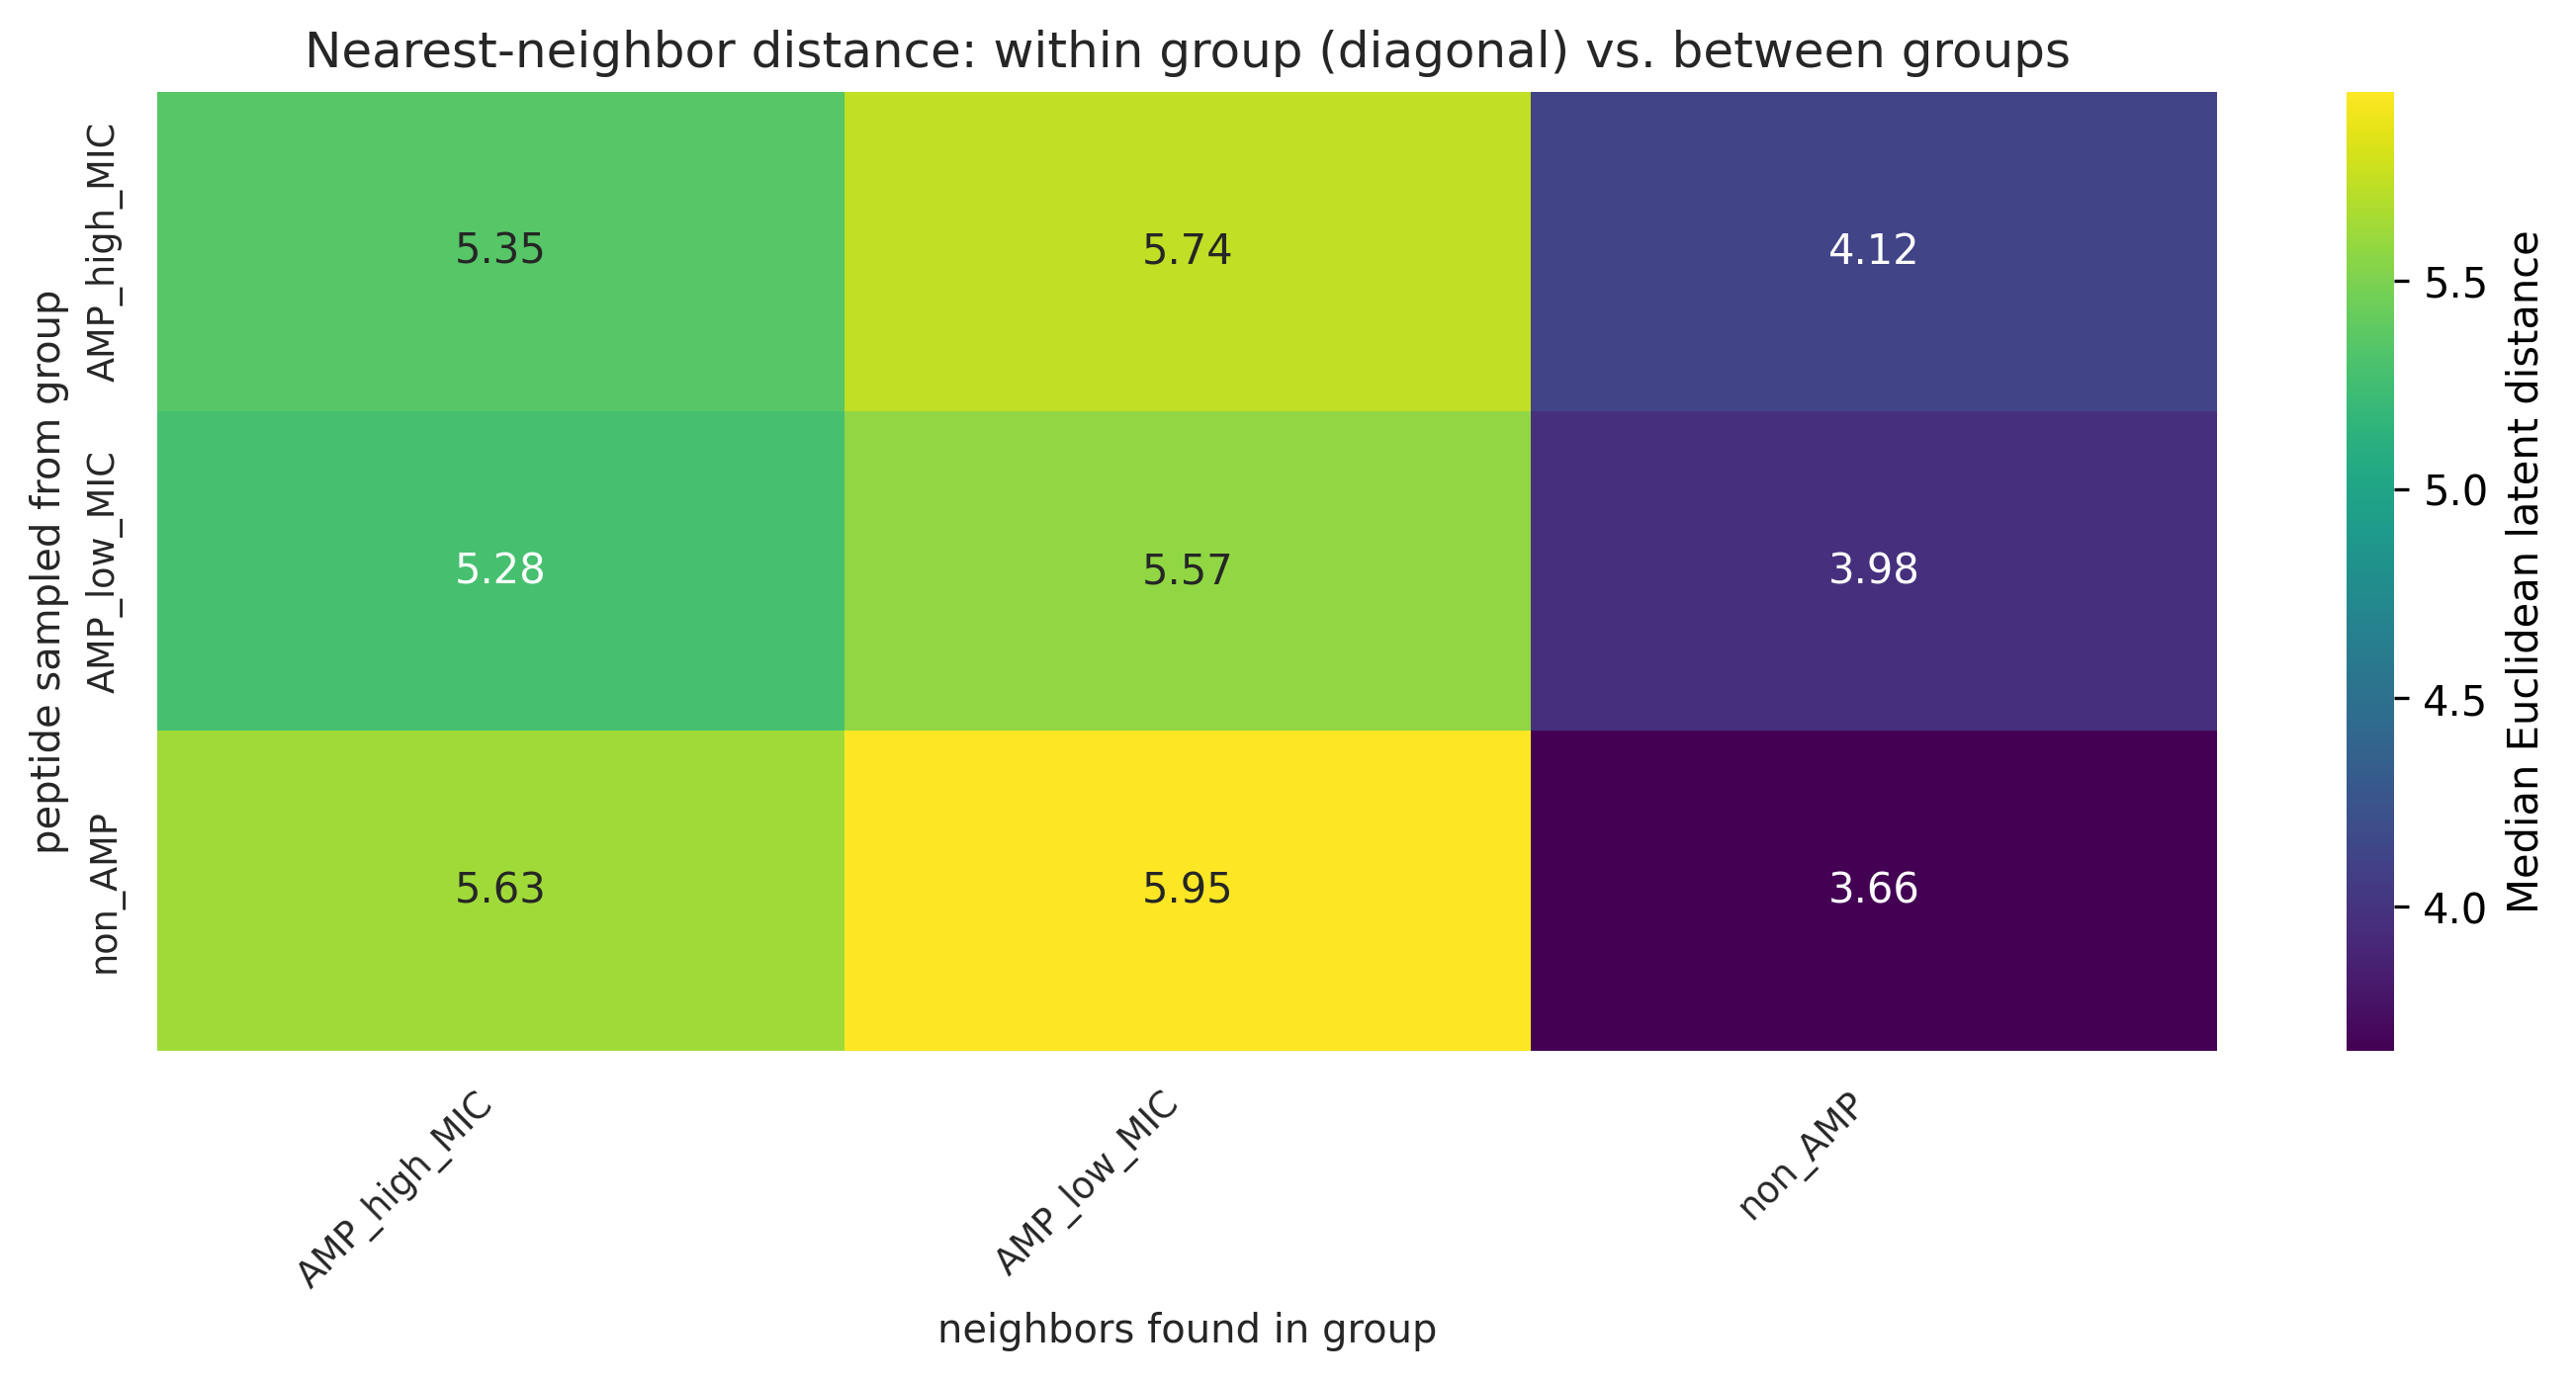

In [20]:
axes = peptide_space_visualizer.separation_heatmap(peptide_space_result_k100, between_result_k100)
display(axes.figure)
plt.close(axes.figure)

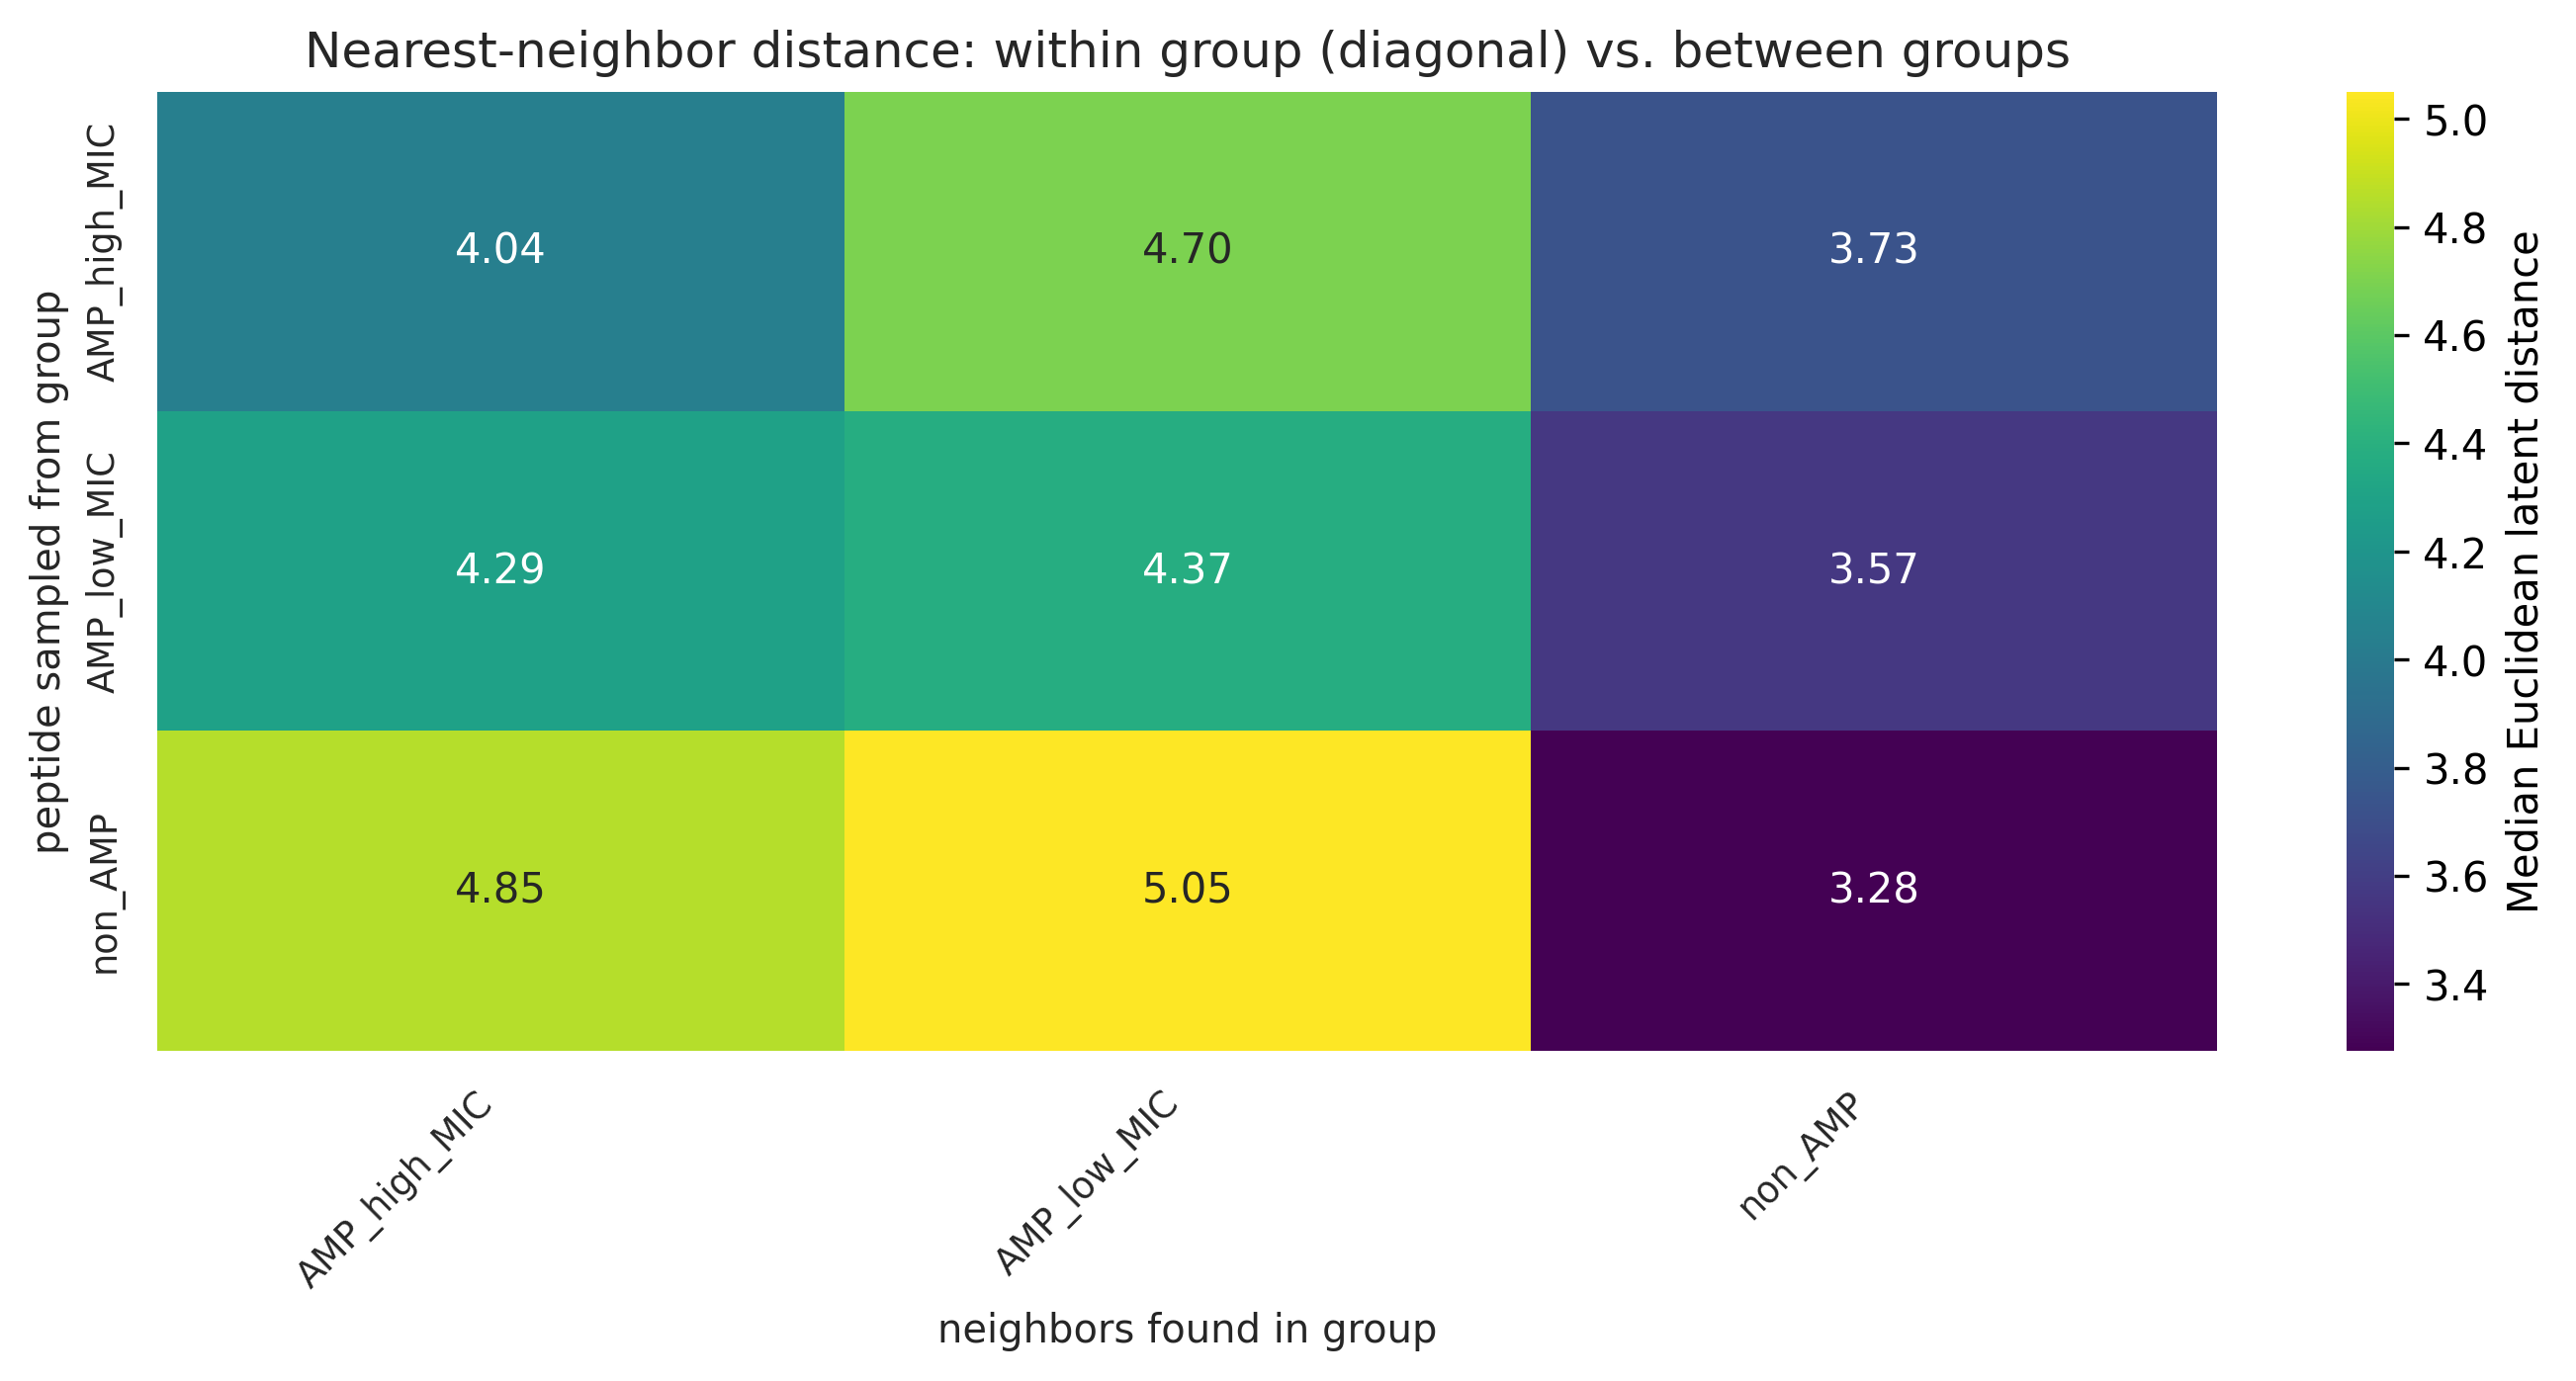

In [21]:
axes = peptide_space_visualizer.separation_heatmap(peptide_space_result_k10, between_result_k10)
display(axes.figure)
plt.close(axes.figure)

### Odległość między środkami grup (centroidy)

Powyższe heatmapy to mediana odległości do NAJBLIŻSZYCH sąsiadów -- lokalna miara, nie mówi wprost, jak daleko są od siebie środki (centroidy) grup. Tu jest to policzone wprost: dla każdej pary grup, jeden wektor na grupę (średnia wszystkich jej peptydów w latencie), i dokładna odległość euklidesowa między tymi dwoma wektorami. Na przekątnej 0 (grupa do samej siebie).

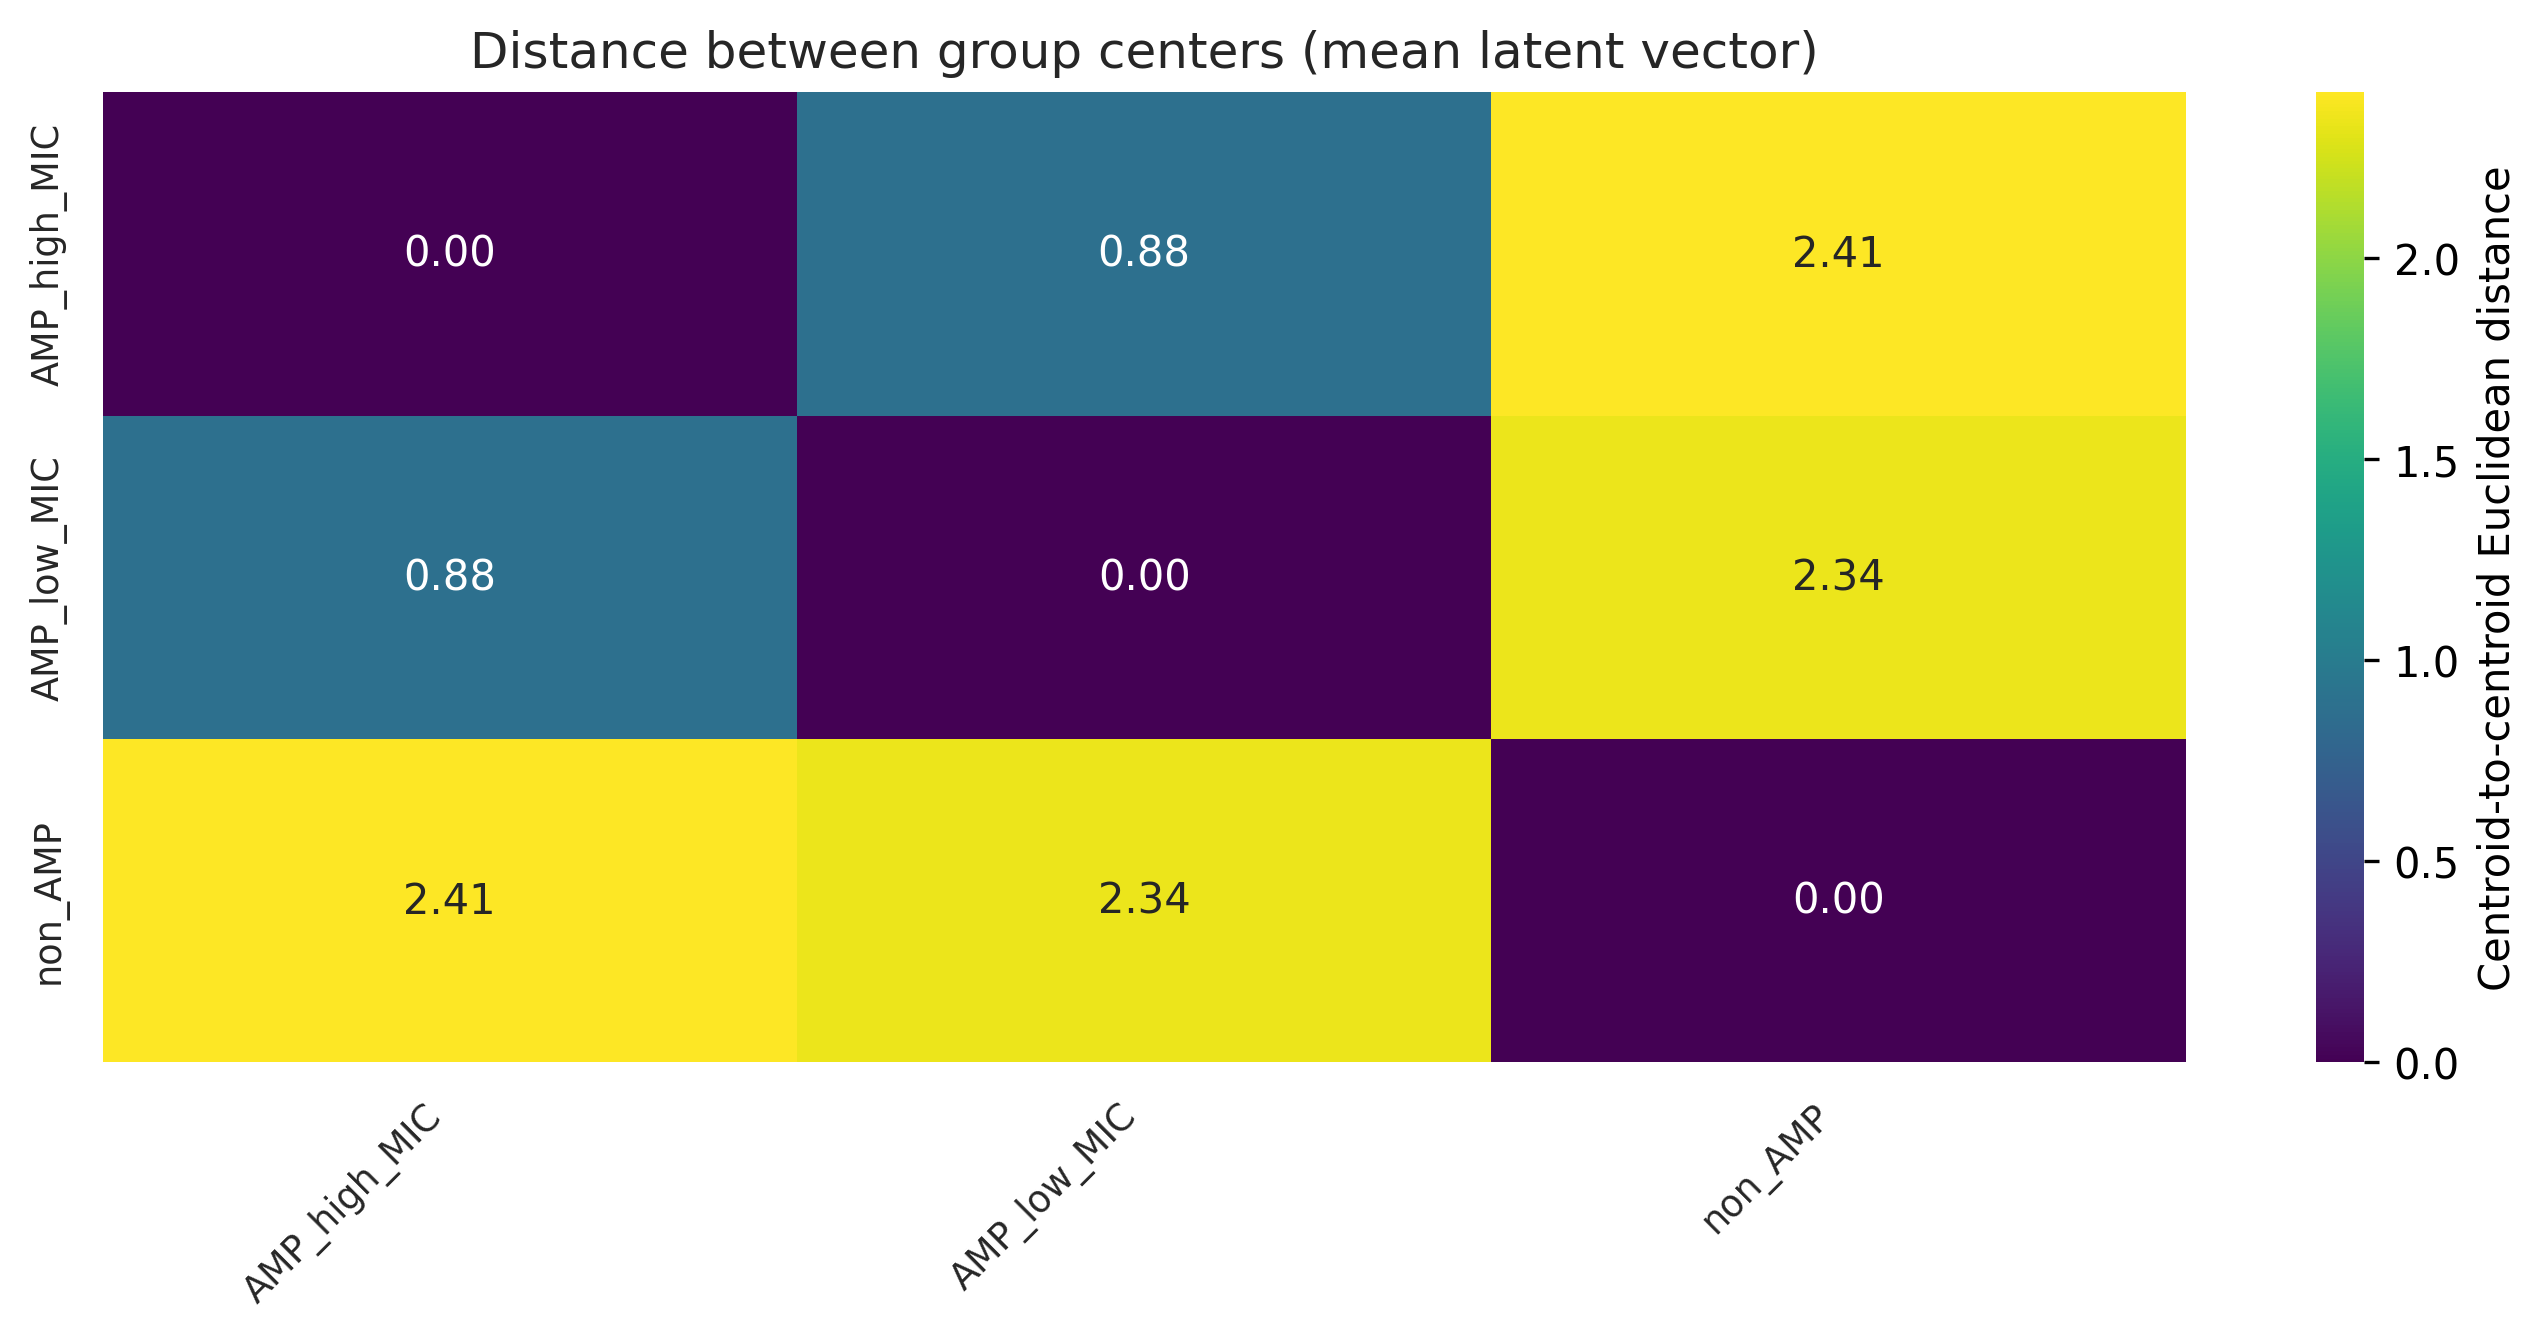

In [22]:
axes = peptide_space_visualizer.centroid_distance_heatmap(between_result_k100)
display(axes.figure)
plt.close(axes.figure)

### Pełne rozkłady, nie tylko mediana z heatmapy

Heatmapa wyżej pokazuje jedną liczbę (medianę) na parę grup -- tu jest cały rozkład. Jeden panel na grupę: na osi X każda inna grupa (własna grupa jako pierwsza, wyróżniona kolorem w legendzie), na osi Y rozkład odległości do jej najbliższych sąsiadów w danej grupie. Pozwala zobaczyć, czy grupy faktycznie się rozdzielają, czy tylko mediana jest inna, a rozkłady się nakładają.

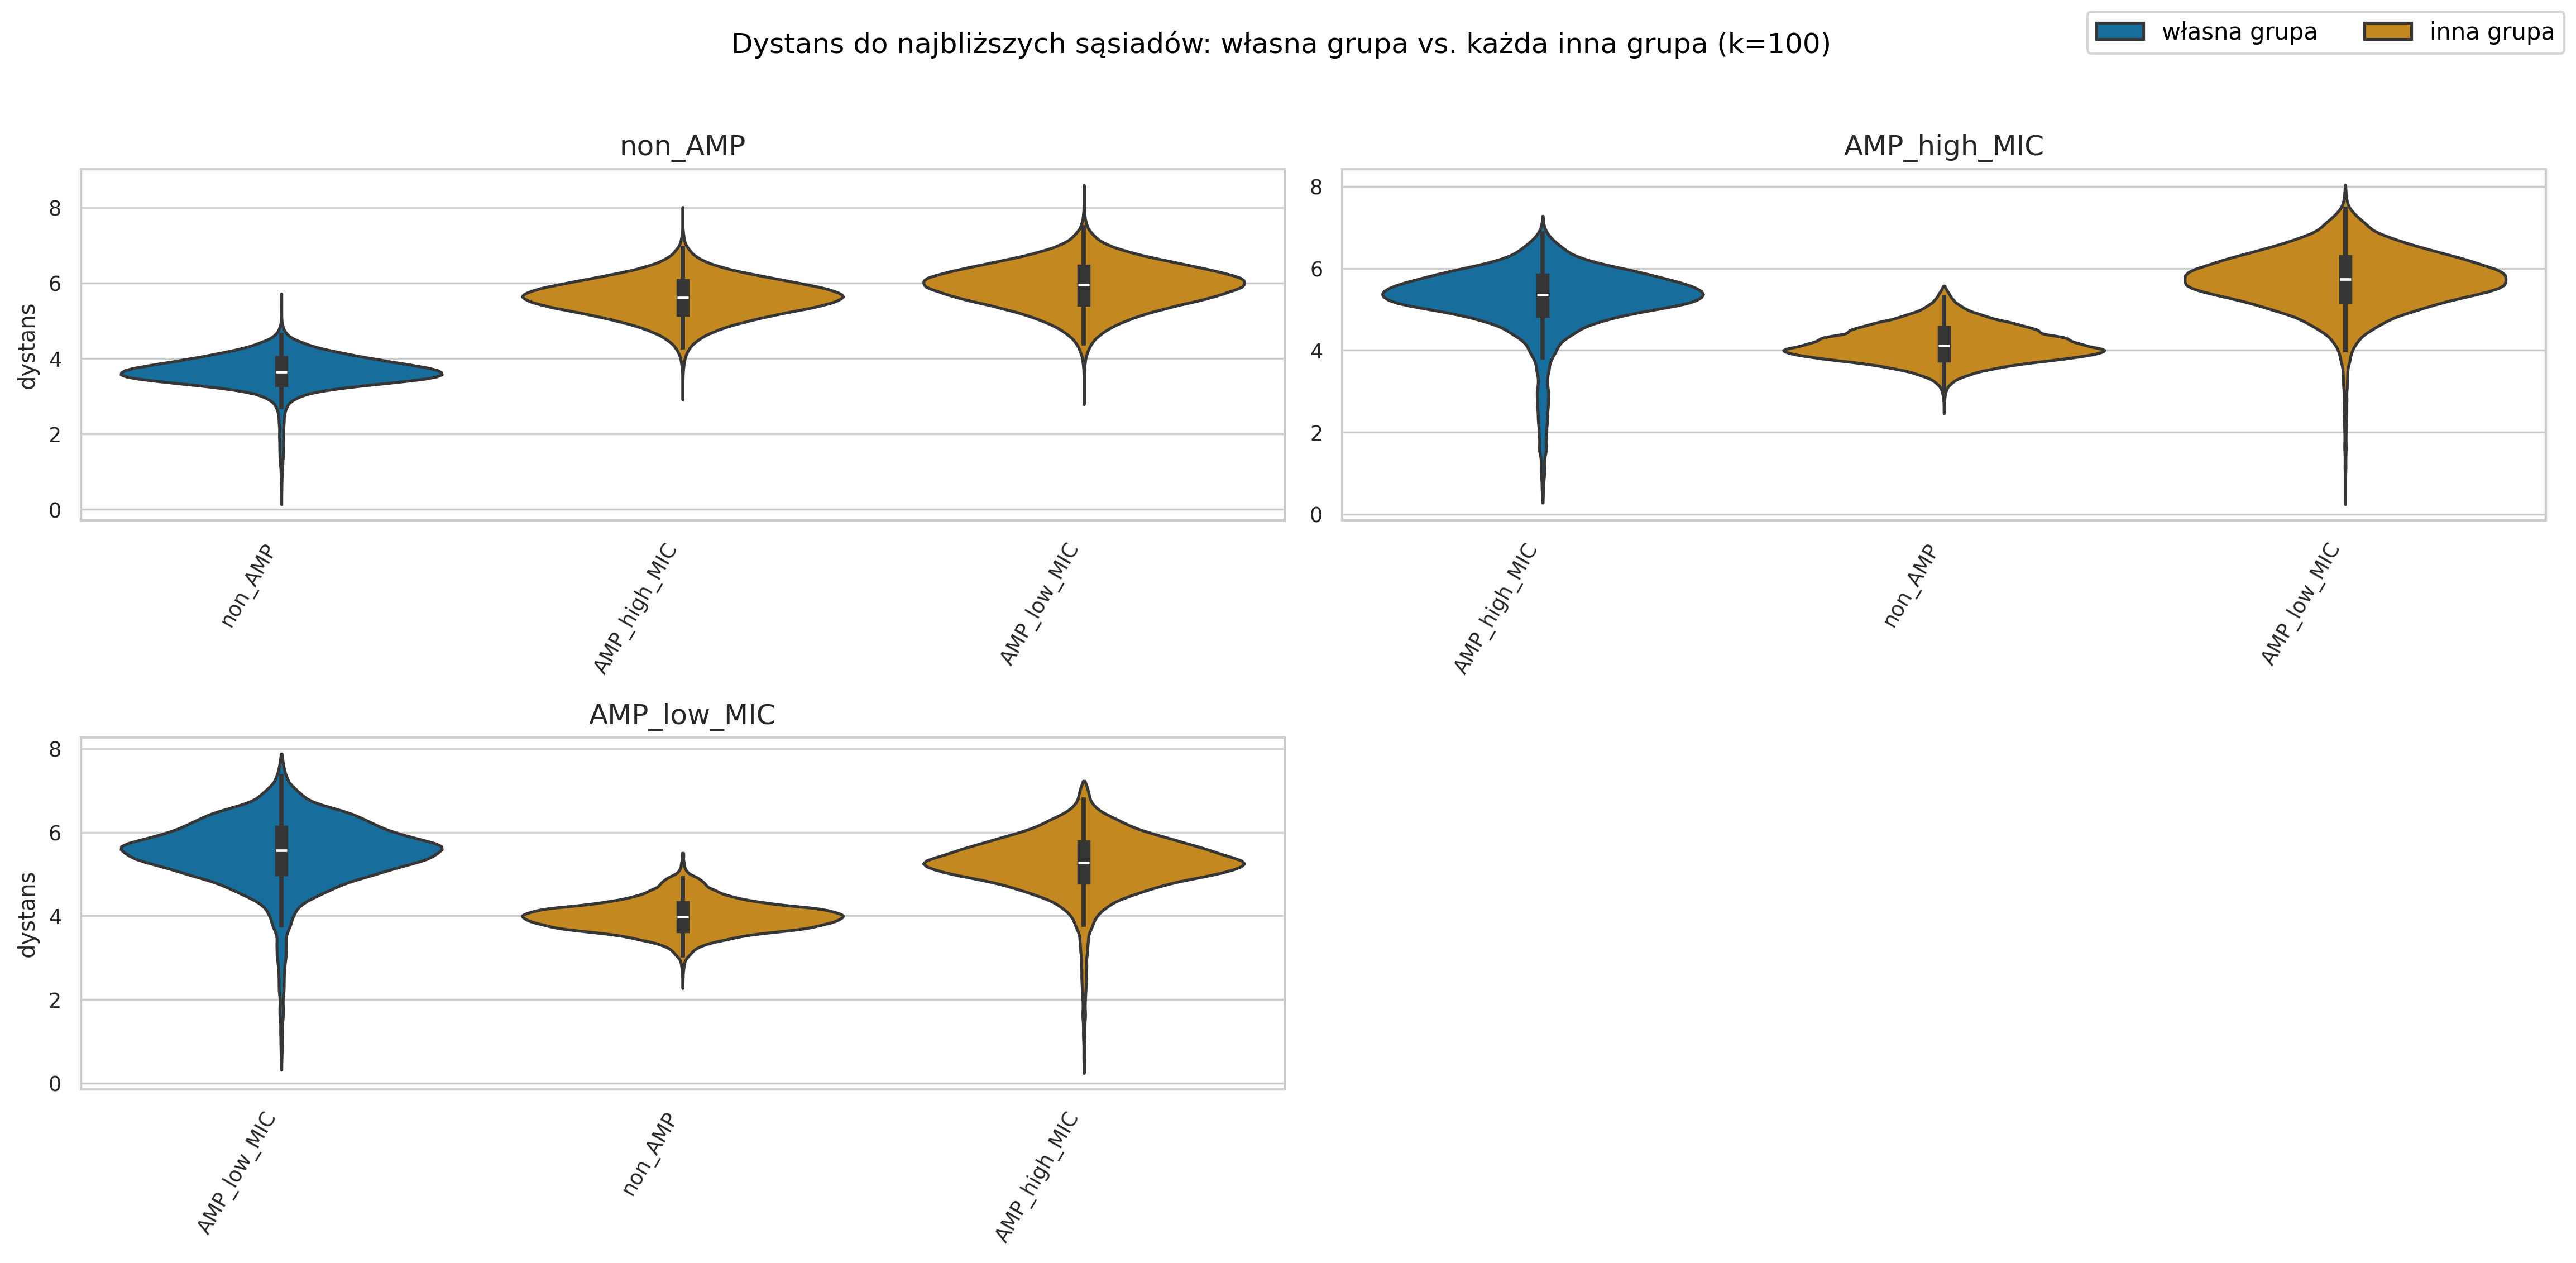

In [23]:
figure = peptide_space_visualizer.neighbor_distance_by_reference(peptide_space_result_k100, between_result_k100)
display(figure)
plt.close(figure)

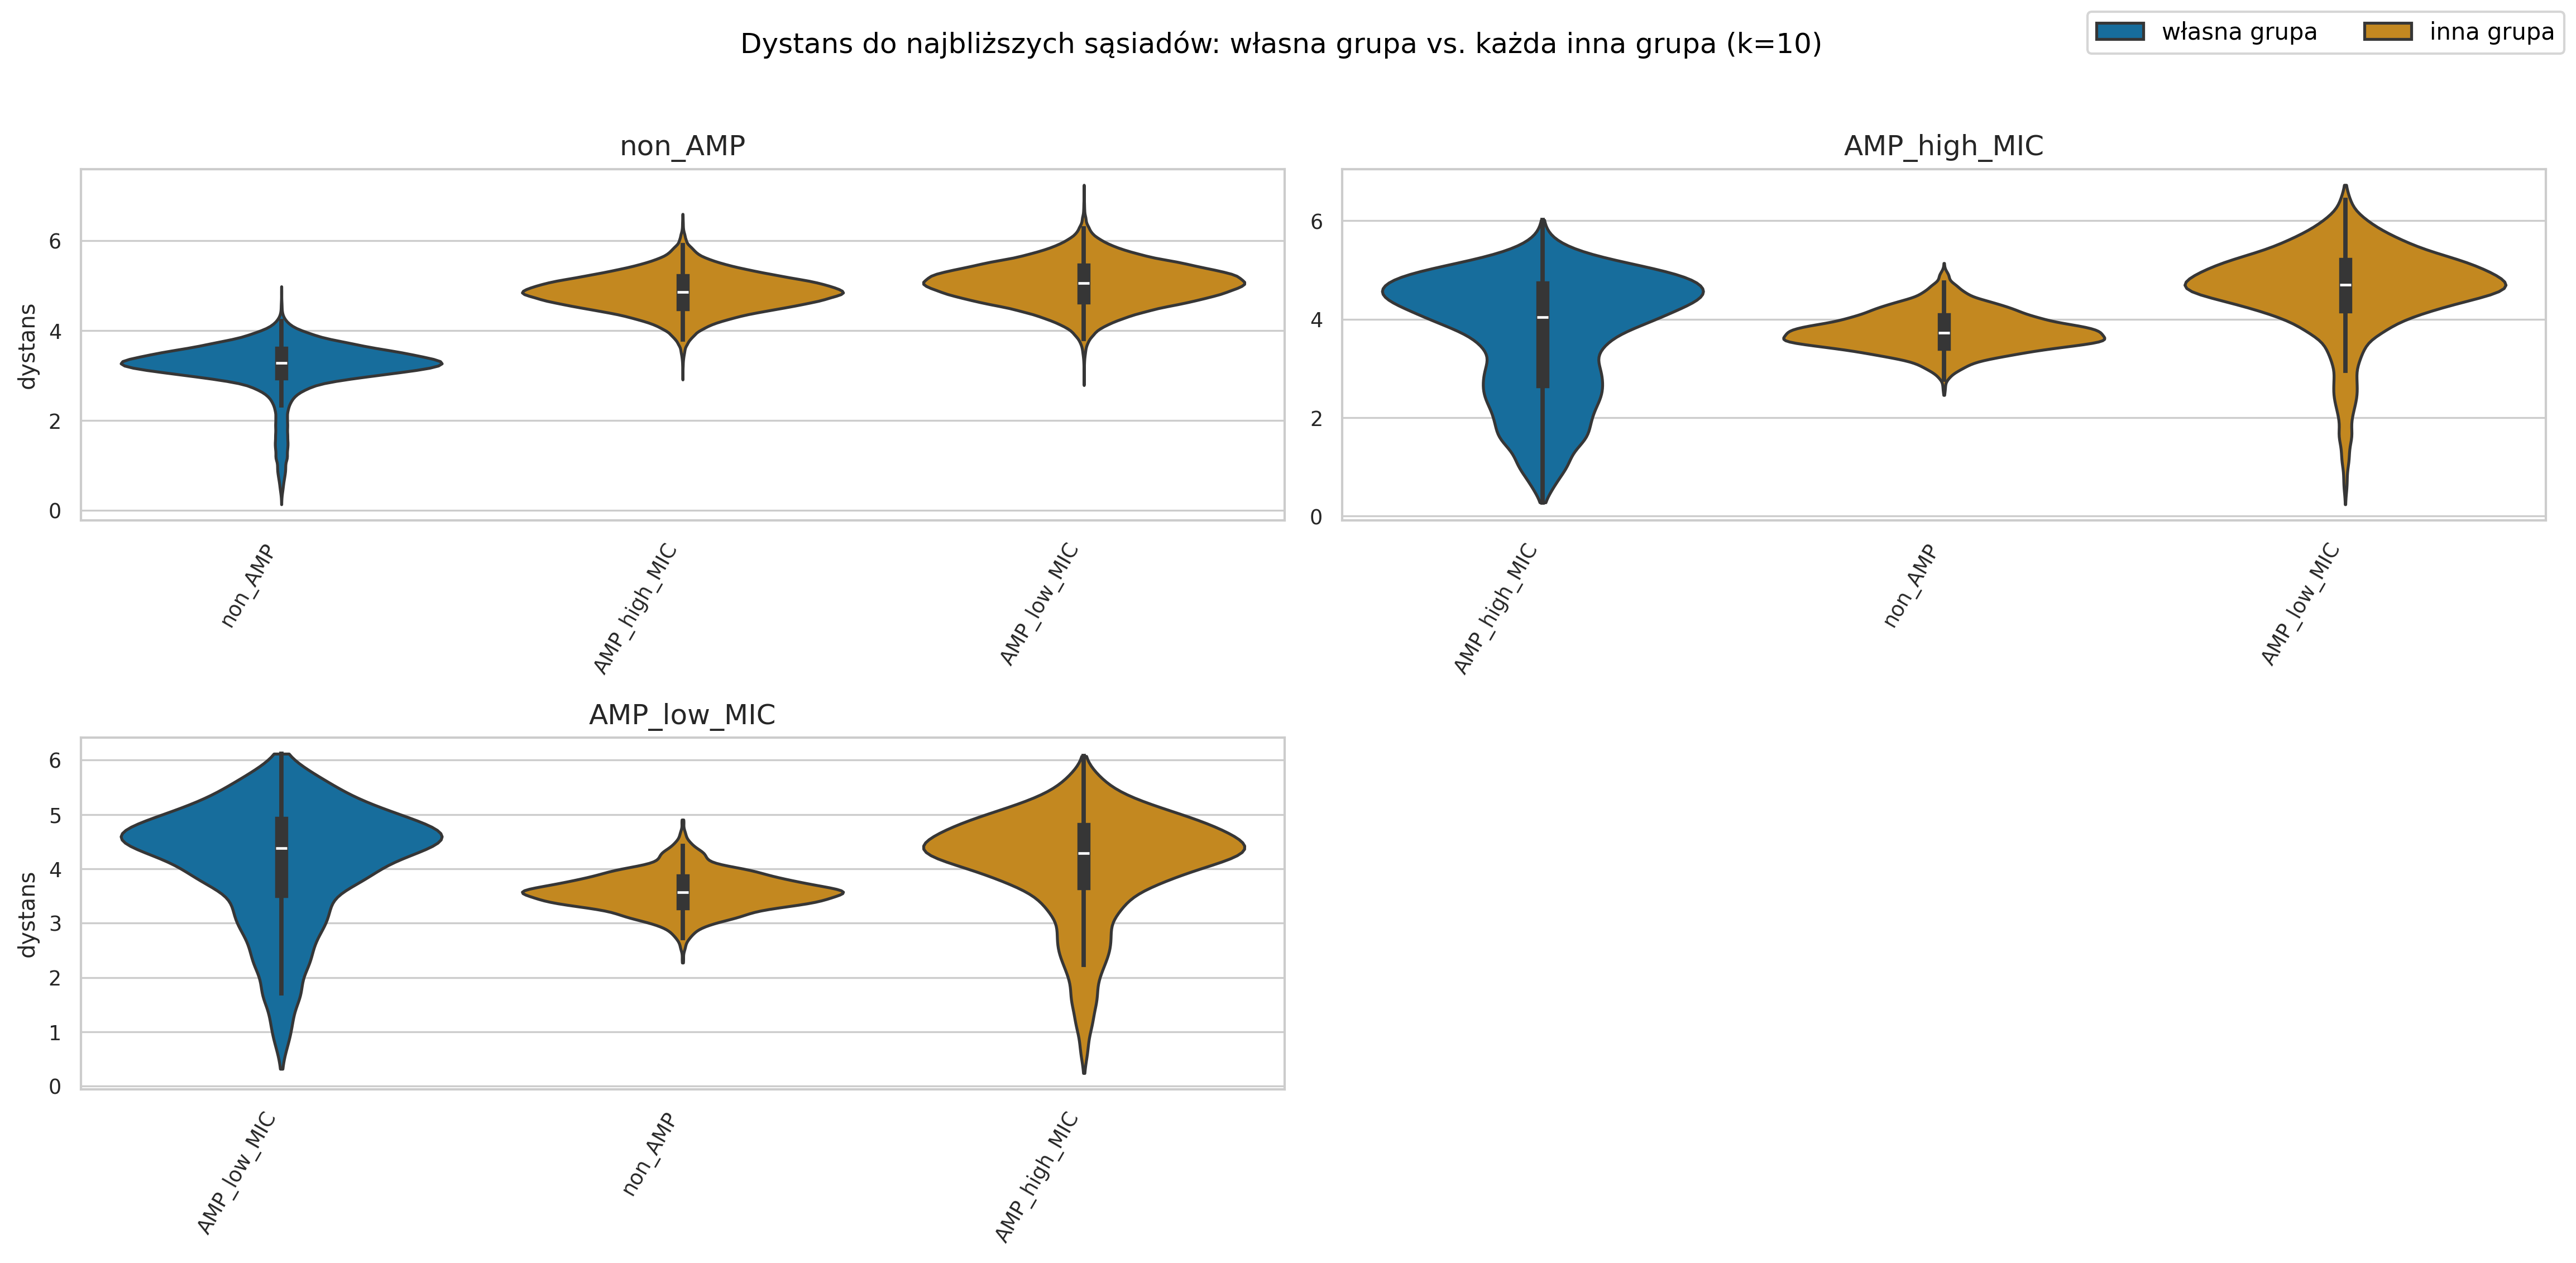

In [24]:
figure = peptide_space_visualizer.neighbor_distance_by_reference(peptide_space_result_k10, between_result_k10)
display(figure)
plt.close(figure)

### Podsumowanie liczbowe: within vs. between (k=100, k=10) i centroidy

Jedna tabela, jeden wiersz na grupę: mediana within, jej NAJBLIŻSZA inna grupa i mediana between do niej (osobno dla k=100 i k=10), oraz -- niezależnie od k -- odległość centroid-do-centroidu do najbliższej innej grupy pod względem centroidów (może to być inna grupa niż najbliższa pod względem sąsiadów).

In [25]:
within_k100 = peptide_space_result_k100.data.groupby("group")["neighbor_distance"].median().rename("within_median_k100")
within_k10 = peptide_space_result_k10.data.groupby("group")["neighbor_distance"].median().rename("within_median_k10")

between_k100 = between_result_k100.data.groupby(["group", "other_group"])["neighbor_distance"].median().reset_index()
between_k10 = between_result_k10.data.groupby(["group", "other_group"])["neighbor_distance"].median().reset_index()
centroid = between_result_k100.diagnostics["centroid_distance"]

nearest_k100 = between_k100.loc[between_k100.groupby("group")["neighbor_distance"].idxmin()].set_index("group")
nearest_k10 = between_k10.loc[between_k10.groupby("group")["neighbor_distance"].idxmin()].set_index("group")
nearest_centroid = centroid.loc[centroid.groupby("group")["centroid_distance"].idxmin()].set_index("group")

summary = pd.DataFrame(
    {
        "within_median_k100": within_k100,
        "nearest_other_group_k100": nearest_k100["other_group"],
        "between_median_k100": nearest_k100["neighbor_distance"],
        "ratio_k100": nearest_k100["neighbor_distance"] / within_k100,
        "within_median_k10": within_k10,
        "nearest_other_group_k10": nearest_k10["other_group"],
        "between_median_k10": nearest_k10["neighbor_distance"],
        "ratio_k10": nearest_k10["neighbor_distance"] / within_k10,
        "nearest_other_group_centroid": nearest_centroid["other_group"],
        "centroid_distance_to_nearest_other": nearest_centroid["centroid_distance"],
    }
).sort_values("ratio_k100")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
display(summary)

,within_median_k100,nearest_other_group_k100,between_median_k100,ratio_k100,within_median_k10,nearest_other_group_k10,between_median_k10,ratio_k10,nearest_other_group_centroid,centroid_distance_to_nearest_other
group,,,,,,,,,,
AMP_low_MIC,5.566909,non_AMP,3.977584,0.714505,4.374897,non_AMP,3.567345,0.815412,AMP_high_MIC,0.877927
AMP_high_MIC,5.349163,non_AMP,4.117523,0.769751,4.036625,non_AMP,3.728369,0.923635,AMP_low_MIC,0.877927
non_AMP,3.655918,AMP_high_MIC,5.625768,1.538811,3.276901,AMP_high_MIC,4.853111,1.481006,AMP_low_MIC,2.337289


**Wniosek:**

**1. Po sąsiadach (k=100 i k=10): obie grupy AMP wyglądają na "połknięte" przez `non_AMP`, ale to efekt rozmiaru, nie geometrii.** `ratio = mediana between / mediana within`:

| grupa | within k100 | najbliższa inna (k100) | ratio k100 | within k10 | najbliższa inna (k10) | ratio k10 |
|---|---|---|---|---|---|---|
| AMP_high_MIC | 5.35 | non_AMP: 4.12 | 0.77 | 4.04 | non_AMP: 3.73 | 0.92 |
| AMP_low_MIC | 5.57 | non_AMP: 3.98 | 0.71 | 4.37 | non_AMP: 3.57 | 0.82 |
| non_AMP | 3.66 | AMP_high_MIC: 5.63 | 1.54 | 3.28 | AMP_high_MIC: 4.85 | 1.48 |

Dla obu grup AMP ratio < 1 przy obu k -- typowy peptyd AMP ma statystycznie bliższego sąsiada w ogromnym `non_AMP` (226 084 peptydów) niż we własnej, dużo mniejszej grupie (809/366). Ściślejsze k=10 zmniejsza ten efekt (0.77->0.92, 0.71->0.82) ale go nie odwraca. Z perspektywy `non_AMP` jest odwrotnie: ratio > 1, czyli WŁASNI sąsiedzi są bliżej niż jakikolwiek AMP -- ta asymetria to podpis czystej gęstości/wielkości próby, nie realnej separacji: w dużym gęstym zbiorze każdy (także obcy) punkt ma szansę trafić na bliskiego sąsiada, w małym rzadkim zbiorze -- nie.

**2. Odległość CENTROID-do-centroidu pokazuje wyraźną, spójną biologicznie strukturę, i to jest właściwa odpowiedź na "czy grupy się w ogóle grupują":**

- `AMP_high_MIC` <-> `AMP_low_MIC`: centroidy 0.88 od siebie -- bardzo blisko.
- `AMP_high_MIC` <-> `non_AMP`: centroidy 2.41 od siebie.
- `AMP_low_MIC` <-> `non_AMP`: centroidy 2.34 od siebie.

Czyli: centrum "bycia AMP" (niezależnie od poziomu MIC) siedzi w latencie ~2.7x dalej od centrum `non_AMP` niż od siebie nawzajem -- **status AMP/nie-AMP zostawia wyraźny ślad w środku ciężkości grupy**, mimo że model był regularyzowany, żeby $z$ tego wprost nie kodował. Za to poziom MIC WEWNĄTRZ grupy AMP (`high` vs `low`) prawie nie rozdziela centroidów (0.88 -- najmniejsza odległość w całym zbiorze) -- co jest akurat zgodne z celem modelu: $c_{MIC}$ miał być zakodowany w warunku $c$, nie w $z$, i tu dokładnie to widać.

**Podsumowanie:** sąsiedzi mówią "AMP jest zanurzony w non_AMP" (artefakt wielkości grupy), a centroidy mówią "AMP i non_AMP faktycznie leżą w innych miejscach, ale high-MIC i low-MIC prawie się nie różnią" -- dwa różne pytania, dwie różne (i obie prawdziwe) odpowiedzi.
